In [1]:
library(miloR)
library(SingleCellExperiment)
library(scater)
#library(scran)
library(dplyr)
library(patchwork)
library(Seurat)
library(Signac)

Loading required package: edgeR

Loading required package: limma

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedi

In [2]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.7 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /tscc/nfs/home/welison/miniconda3/envs/milor/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] Signac_1.16.0               Seurat_5.4.0               
 [3] SeuratObject_5.3.0          sp_2.2-1                   
 [5] patchwork_1.3.2             dplyr_1.2.0                
 [7] scater_

In [2]:
#adata <- readRDS('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/Final_fNIH_Liver_10X_Multiome_object_v3_Gaulton_Peaks_TSCC_Fragments.rds')
adata <- readRDS('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/subtypes/Hepatocytes/Hepatocytes_subtype_UnionPeaks_seurat_object.RDS')
adata

An object of class Seurat 
986876 features across 233608 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [3]:
Idents(adata) <- adata$donor_demux
adata.sub <- subset(adata, downsample = 250)
adata.sub

An object of class Seurat 
986876 features across 21500 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [4]:
adata <- NULL
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,11403815,609.1,18558662,991.2,13842013,739.3
Vcells,1340325008,10225.9,12168427332,92837.8,14556855334,111060.0


In [5]:
adata.sce <- as.SingleCellExperiment(adata.sub, assay = 'RNA')
adata.sce

class: SingleCellExperiment 
dim: 36601 21500 
metadata(0):
assays(2): counts logcounts
rownames(36601): MIR1302-2HG FAM138A ... AC007325.4 AC007325.2
rowData names(0):
colnames(21500): MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1
  MM_1341_1_2_MM_1337_1_2_AAACGTACAGGTTACC-1 ...
  QY_2410_2_QY_2409_2_TTTGTGTTCAGGTTTA-1
  QY_2410_2_QY_2409_2_TTTGTGTTCCTTCGTA-1
colData names(78): orig.ident nCount_RNA ... nFeature_Subtype.Peaks
  ident
reducedDimNames(7): PCA HARMONY.RNA ... UMAP.ATAC UMAP.WNN
mainExpName: RNA
altExpNames(0):

In [6]:
#logcounts(adata.sce) <- log(counts(adata.sce) + 1)
#adata.sce <- runPCA(adata.sce, ncomponents=30)
#adata.sce <- runUMAP(adata.sce)
#
#plotUMAP(adata.sce)

In [7]:
adata_milo <- Milo(adata.sce)
adata_milo

class: Milo 
dim: 36601 21500 
metadata(0):
assays(2): counts logcounts
rownames(36601): MIR1302-2HG FAM138A ... AC007325.4 AC007325.2
rowData names(0):
colnames(21500): MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1
  MM_1341_1_2_MM_1337_1_2_AAACGTACAGGTTACC-1 ...
  QY_2410_2_QY_2409_2_TTTGTGTTCAGGTTTA-1
  QY_2410_2_QY_2409_2_TTTGTGTTCCTTCGTA-1
colData names(78): orig.ident nCount_RNA ... nFeature_Subtype.Peaks
  ident
reducedDimNames(7): PCA HARMONY.RNA ... UMAP.ATAC UMAP.WNN
mainExpName: RNA
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [8]:
adata_milo <- buildGraph(adata_milo, k = 10, d = 30)

Constructing kNN graph with k:10



In [9]:
adata_milo <- makeNhoods(adata_milo, prop = 0.1, k = 10, d=30, refined = TRUE)

Checking valid object

Running refined sampling with reduced_dim



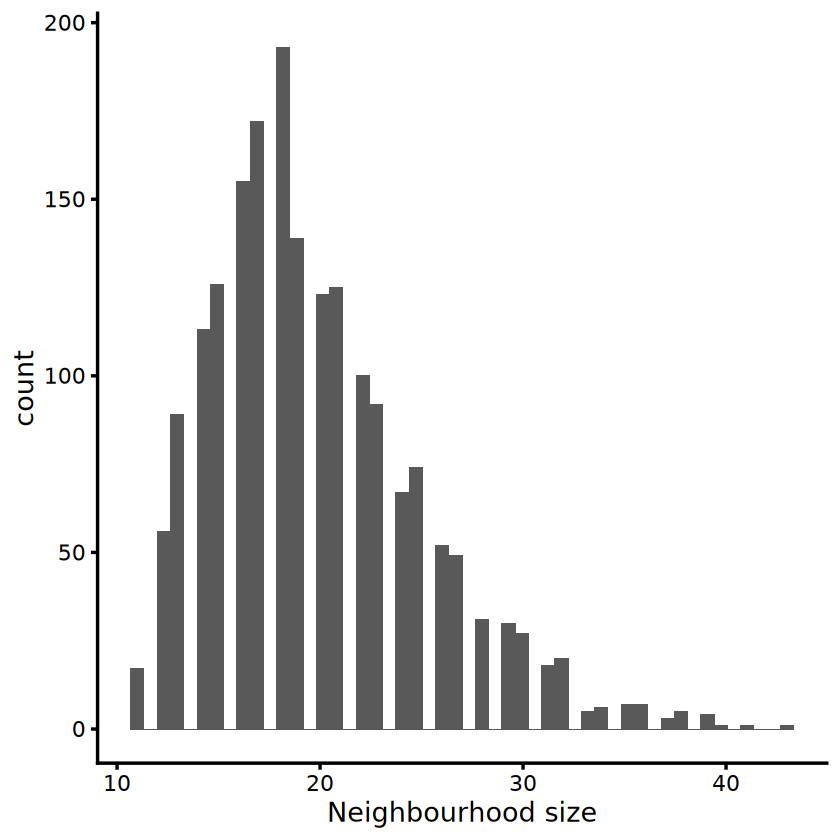

In [10]:
plotNhoodSizeHist(adata_milo)

In [11]:
adata_milo@colData

DataFrame with 21500 rows and 78 columns
                                              orig.ident nCount_RNA
                                             <character>  <numeric>
MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1 SeuratProject       3440
MM_1341_1_2_MM_1337_1_2_AAACGTACAGGTTACC-1 SeuratProject       3866
MM_1341_1_2_MM_1337_1_2_AAACGTACATTGCAGC-1 SeuratProject      12210
MM_1341_1_2_MM_1337_1_2_AAAGCACCAATTGAGA-1 SeuratProject      10586
MM_1341_1_2_MM_1337_1_2_AAAGCCCGTGCTTAGA-1 SeuratProject       3966
...                                                  ...        ...
QY_2410_2_QY_2409_2_TTTGGTGCACTTGTTC-1     SeuratProject       6770
QY_2410_2_QY_2409_2_TTTGTGGCACAGAAAC-1     SeuratProject      15067
QY_2410_2_QY_2409_2_TTTGTGGCACCCACAG-1     SeuratProject       5317
QY_2410_2_QY_2409_2_TTTGTGTTCAGGTTTA-1     SeuratProject      11800
QY_2410_2_QY_2409_2_TTTGTGTTCCTTCGTA-1     SeuratProject       2273
                                           nFeature_RNA percent.mt
        

In [12]:
adata_milo <- countCells(adata_milo, meta.data = data.frame(colData(adata_milo)), samples="donor_demux")

Checking meta.data validity

Counting cells in neighbourhoods



In [13]:
head(nhoodCounts(adata_milo))

  [[ suppressing 86 column names ‘HL200707’, ‘HL160029’, ‘HL170049’ ... ]]



6 x 86 sparse Matrix of class "dgCMatrix"
                                                                               
1 . . . . . . . . . . 1 . 1 . . . . . . . . . . . . . . . . . . . . . . . . . .
2 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1 . .
3 . . . . . . . . . . . . . . . 1 . . . . . . . . . . . . . . . . . . . . . . .
4 . . . . . . . . . . . . 6 . . . . . . . . . . . . . . . . . . . . . . . . . .
5 . . . . . . . . . . . . . . . . 2 . . . . 4 . . . . . . . . . . . . . . . . .
6 . . . . . . . . . . . . . . . . . . . . . . . . . . 1 . . . . 3 . . . 2 . . .
                                                                               
1 3  . . . . 6 2 1 . . . 1 . . . . . . .  . . . . . . . . . . 1 . .  . . . .  .
2 . 24 . . . . . . . . . . . . . . . . .  . . . . . . . . . . . . .  . . . .  .
3 .  . . . . . . 1 . . . . . . . . . . .  . . . . . . . . . . . . . 24 . . .  .
4 3  . . . 5 1 2 1 . . . 8 . . . . . . .  . . . . . . . . 3 . 2 . .  . . . .  

In [14]:
fibrosis_design <- data.frame(colData(adata_milo))[,c("donor_demux", "Fibrosis.stage")]
fibrosis_design <- distinct(fibrosis_design)
rownames(fibrosis_design) <- fibrosis_design$donor_demux
## Reorder rownames to match columns of nhoodCounts(milo)
fibrosis_design <- fibrosis_design[colnames(nhoodCounts(adata_milo)), , drop=FALSE]

fibrosis_design

,donor_demux,Fibrosis.stage
,<chr>,<int>
HL200707,HL200707,0
HL160029,HL160029,0
HL170049,HL170049,4
HL200805,HL200805,0
HL210726,HL210726,4
HL170060,HL170060,2
HL230316,HL230316,0
HL210120,HL210120,3
HL160042,HL160042,0


In [15]:
adata_milo <- calcNhoodDistance(adata_milo, d=30)

'as(<dgTMatrix>, "dgCMatrix")' is deprecated.
Use 'as(., "CsparseMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").



In [16]:
rownames(fibrosis_design) <- fibrosis_design$donor_demux
da_results <- testNhoods(adata_milo, design = ~ Fibrosis.stage, design.df = fibrosis_design)

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Performing spatial FDR correction with k-distance weighting



In [17]:
da_results %>%
  arrange(- SpatialFDR) %>%
  head() 

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
32,0.028040477,12.21088,0.0245508830,0.9953069,0.9953069,32,0.9953069
696,0.065448361,12.19773,0.1311749136,0.9953069,0.9953069,696,0.9953069
1221,0.032073842,12.20244,0.0335602975,0.9953069,0.9953069,1221,0.9953069
1874,0.095324599,12.19451,0.2647790244,0.9953069,0.9953069,1874,0.9953069
563,0.003465433,12.27295,0.0001637216,0.9897939,0.9934386,563,0.9935998
1015,0.001074871,12.17853,0.0001279547,0.9909773,0.9935735,1015,0.9935998


In [18]:
adata_milo

class: Milo 
dim: 36601 21500 
metadata(0):
assays(2): counts logcounts
rownames(36601): MIR1302-2HG FAM138A ... AC007325.4 AC007325.2
rowData names(0):
colnames(21500): MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1
  MM_1341_1_2_MM_1337_1_2_AAACGTACAGGTTACC-1 ...
  QY_2410_2_QY_2409_2_TTTGTGTTCAGGTTTA-1
  QY_2410_2_QY_2409_2_TTTGTGTTCCTTCGTA-1
colData names(78): orig.ident nCount_RNA ... nFeature_Subtype.Peaks
  ident
reducedDimNames(7): PCA HARMONY.RNA ... UMAP.ATAC UMAP.WNN
mainExpName: RNA
altExpNames(0):
nhoods dimensions(2): 21500 1908
nhoodCounts dimensions(2): 1908 86
nhoodDistances dimension(1): 1908
graph names(1): graph
nhoodIndex names(1): 1908
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [19]:
str(adata_milo)

Formal class 'Milo' [package "miloR"] with 19 slots
  ..@ graph              :List of 1
  .. ..$ graph:Class 'igraph'  hidden list of 10
  .. .. ..$ : num 21500
  .. .. ..$ : logi FALSE
  .. .. ..$ : num [1:157983] 2191 2464 7168 8031 8316 ...
  .. .. ..$ : num [1:157983] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ :List of 4
  .. .. .. ..$ : num [1:3] 1 0 1
  .. .. .. ..$ : Named list()
  .. .. .. ..$ : Named list()
  .. .. .. ..$ : Named list()
  .. .. ..$ :<environment: 0x55558e26a368> 
  ..@ nhoods             :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:37734] 1046 3126 9907 9908 10364 11906 12393 13053 13532 13789 ...
  .. .. ..@ p       : int [1:1909] 0 16 41 67 99 127 149 171 195 212 ...
  .. .. ..@ Dim     : int [1:2] 21500 1908
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:21500] "MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1" "MM_1341_1_2_MM_1337_1_2_AAACGTACAG

Adding nhood effect sizes to neighbourhood graph attributes



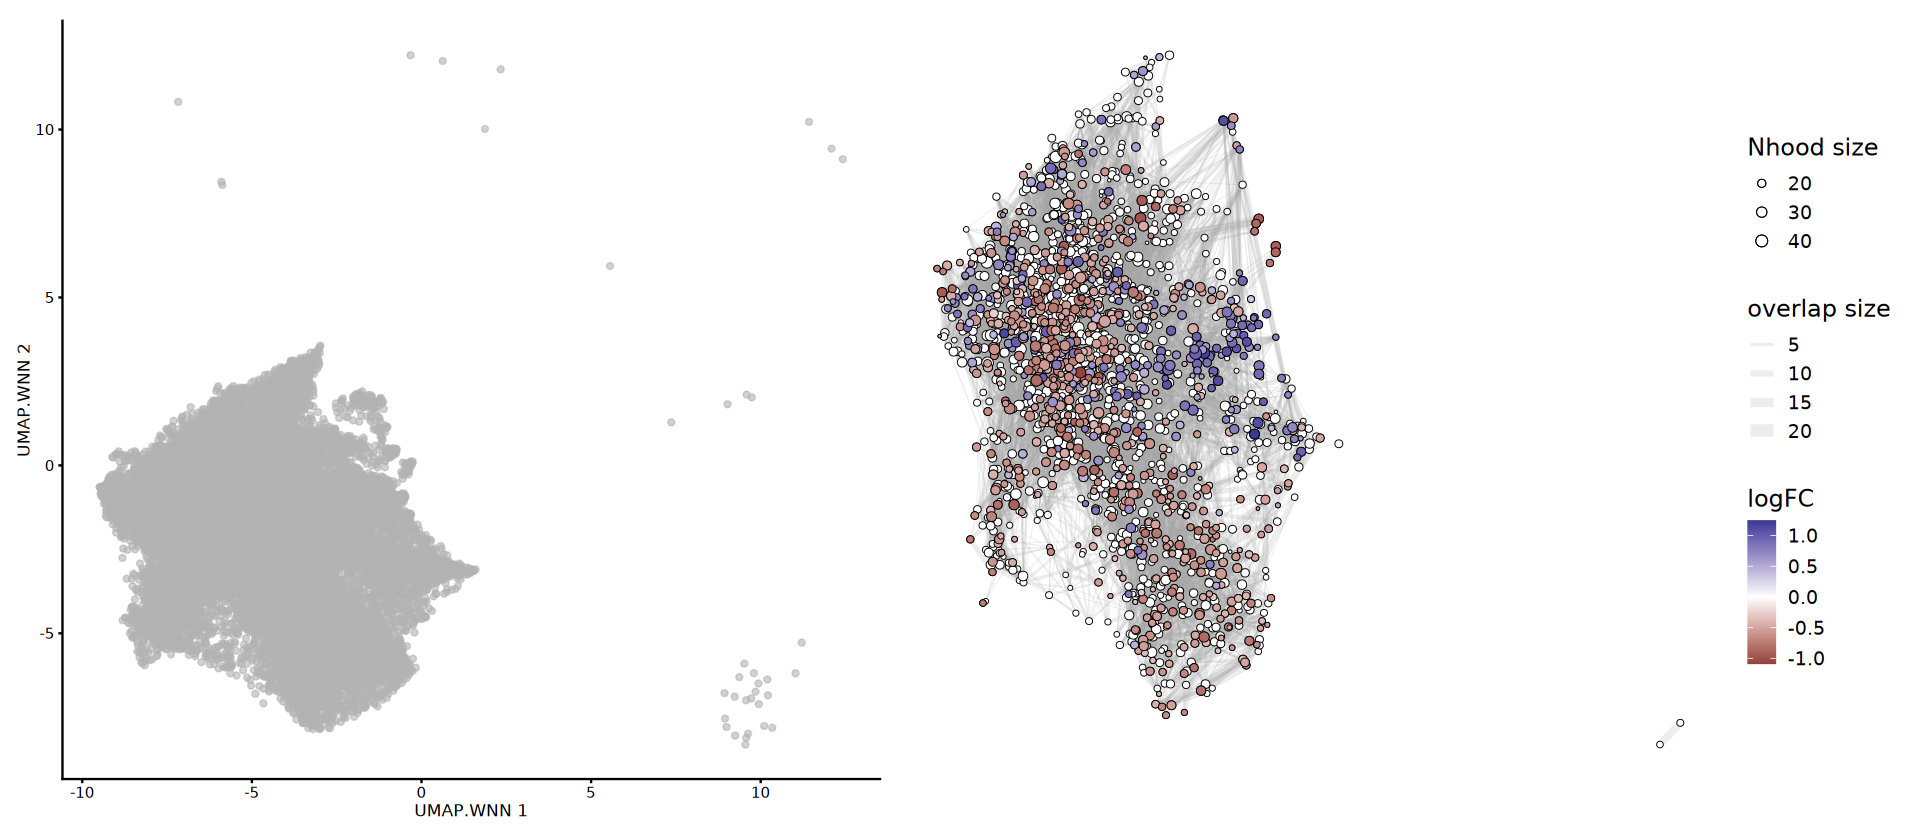

In [20]:
options(repr.plot.width=16)
adata_milo <- buildNhoodGraph(adata_milo)

plotUMAP(adata_milo, dimred = 'UMAP.WNN') + plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.WNN") +
  plot_layout(guides="collect")

In [21]:
reducedDims(adata_milo)

List of length 7
names(7): PCA HARMONY.RNA UMAP.RNA LSI HARMONY.ATAC UMAP.ATAC UMAP.WNN

Adding nhood effect sizes to neighbourhood graph attributes



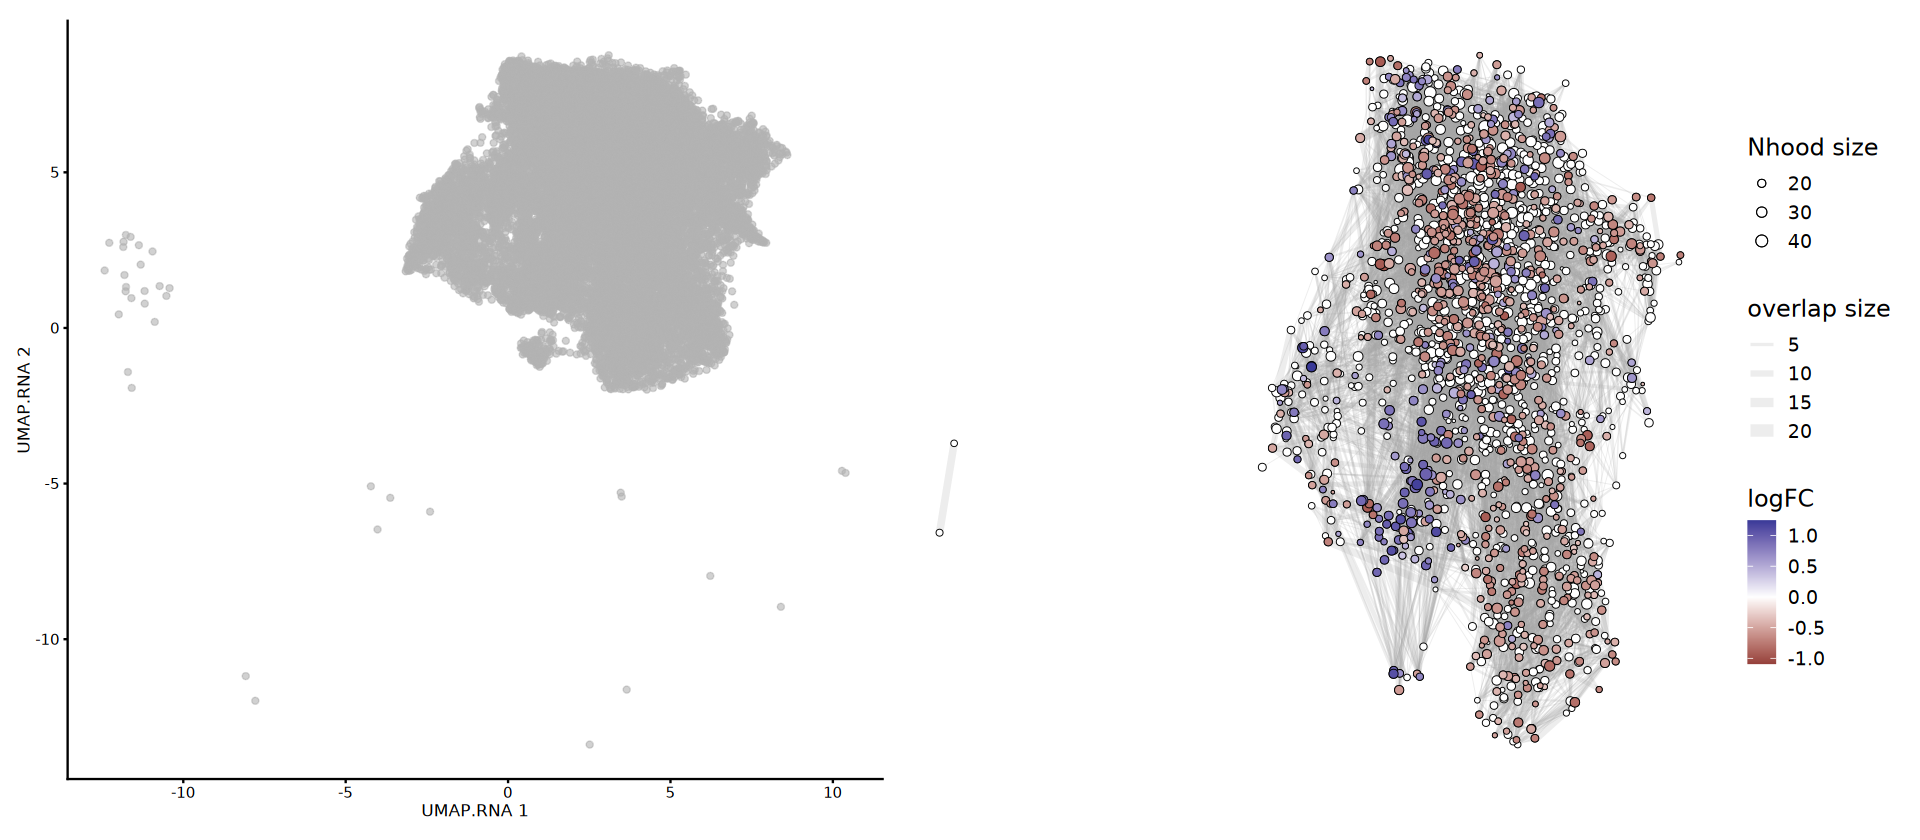

In [22]:
options(repr.plot.width=16)
adata_milo <- buildNhoodGraph(adata_milo)

plotUMAP(adata_milo, dimred = 'UMAP.RNA') + plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.RNA") +
  plot_layout(guides="collect")

Adding nhood effect sizes to neighbourhood graph attributes

Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”


agg_record_4e92227c1994c 
                       2

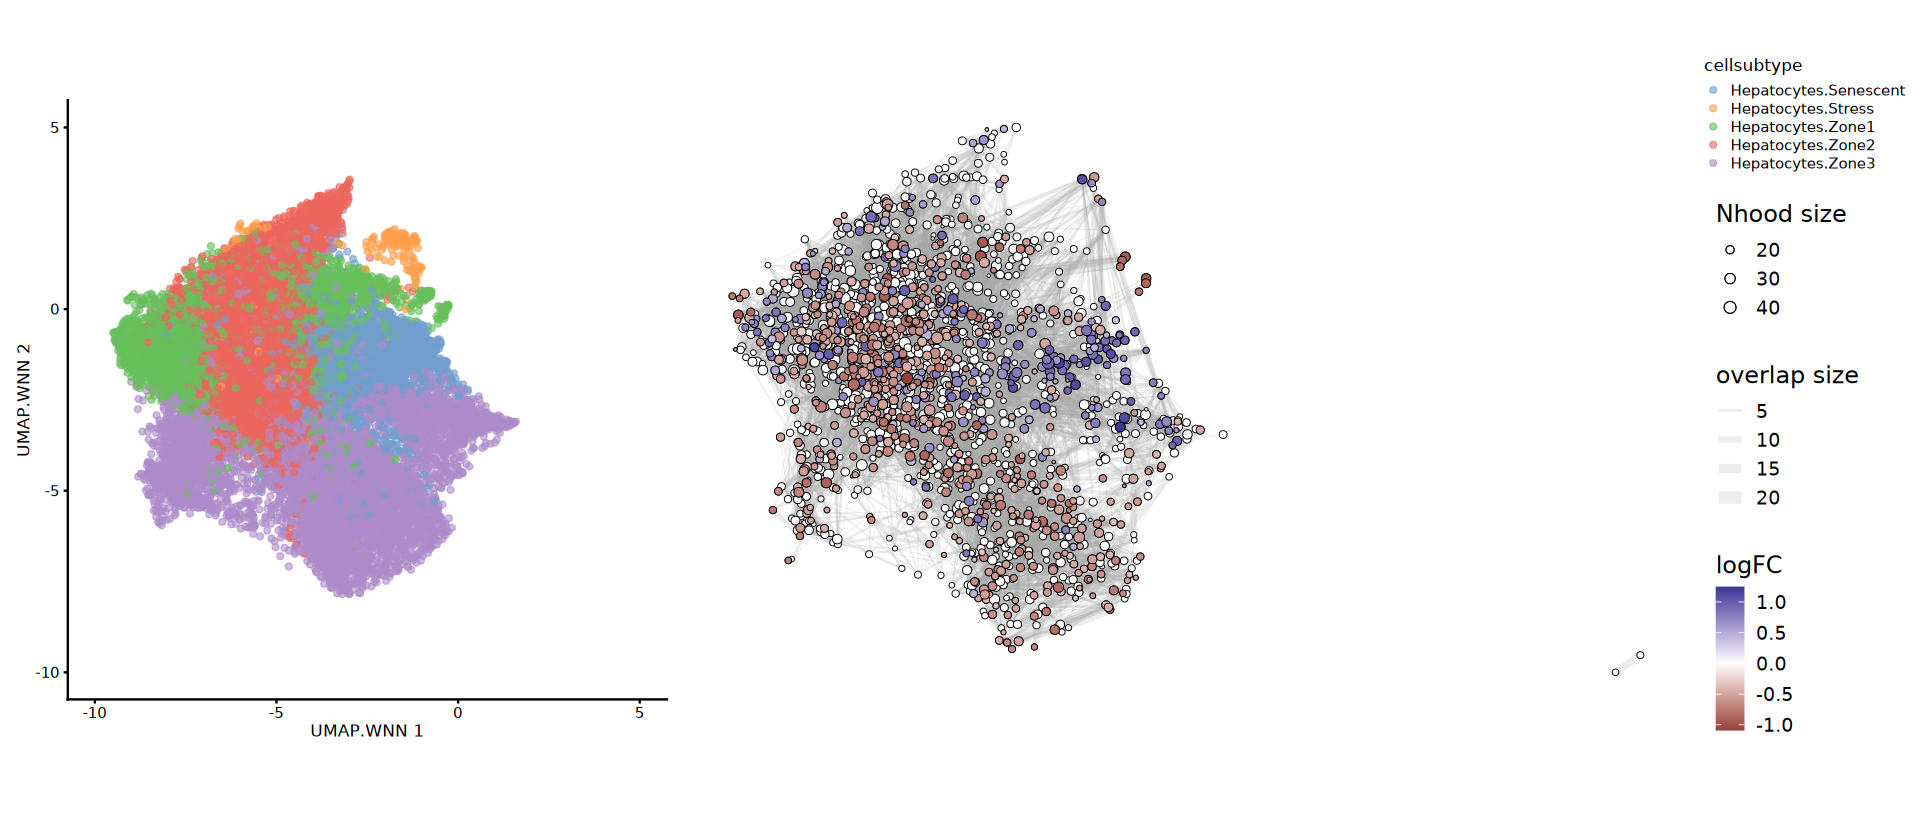

In [23]:
p1 <- plotUMAP(adata_milo, dimred = 'UMAP.WNN', colour_by='cellsubtype') +
  theme(aspect.ratio = 1) + xlim(c(-10,5)) + ylim(c(-10,5))
p2 <- plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.WNN") +
  theme(aspect.ratio = 0.6)

p1 + p2 + plot_layout(guides = "collect")

pdf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_vs_Neighborhoods.pdf', width=16)
p1 + p2 + plot_layout(guides = "collect")
dev.off()

In [28]:
da_results <- annotateNhoods(adata_milo, da_results, 'cellsubtype')
dim(da_results)
head(da_results)

Converting cellsubtype to factor...



[1] 1908    9

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cellsubtype,cellsubtype_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,-0.17623288,12.18822,1.1587247,3.021457e-01,4.229532e-01,1,4.345169e-01,Hepatocytes.Zone2,0.6250000
2,-0.91501963,12.37868,37.6562068,9.418983e-09,1.695417e-07,2,2.206451e-07,Hepatocytes.Zone1,0.9600000
3,-0.74028068,12.26192,28.1255174,1.441532e-07,1.751875e-06,3,2.137127e-06,Hepatocytes.Zone2,0.5384615
4,0.09867614,12.31654,0.1820048,7.512910e-01,8.447043e-01,4,8.505761e-01,Hepatocytes.Zone2,0.9375000
5,-0.31896027,12.30085,2.5087864,1.135719e-01,1.927892e-01,5,1.998519e-01,Hepatocytes.Zone2,0.9285714
6,-0.11755000,12.23447,0.4437479,5.054933e-01,6.316184e-01,6,6.407325e-01,Hepatocytes.Zone2,0.9090909


In [ ]:
da_results <- annotateNhoods(adata_milo, da_results, 'cellsubtype')
dim(da_results)
head(da_results)
plotDAbeeswarm(da_results, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

Converting group_by to factor...



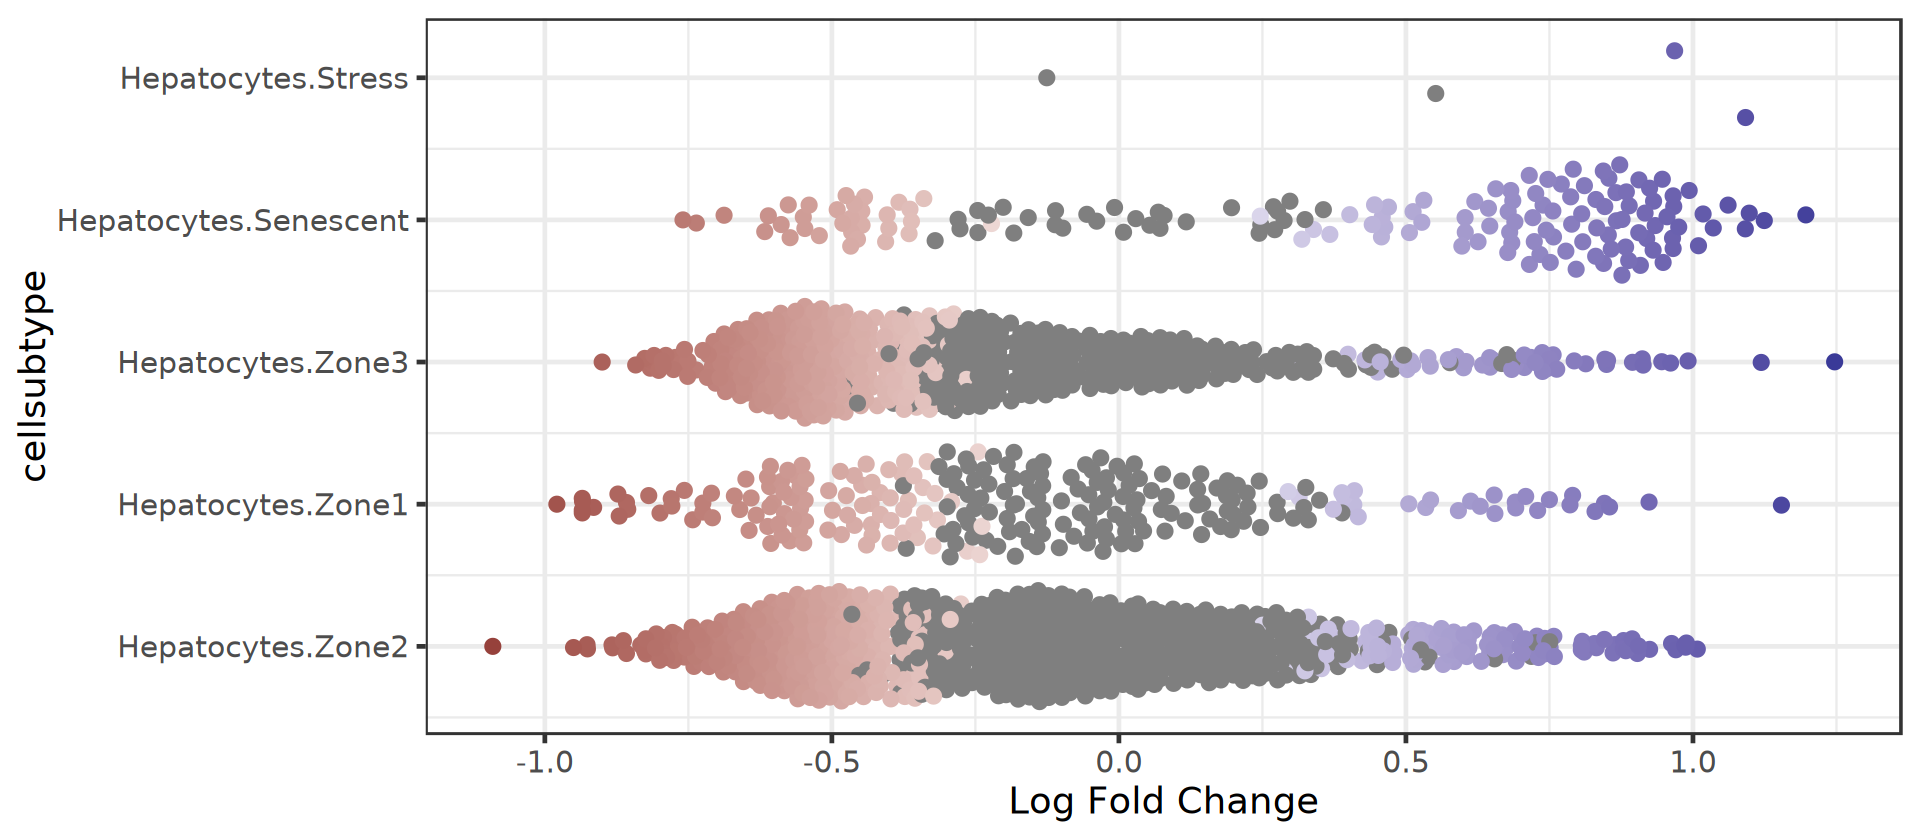

In [29]:
plotDAbeeswarm(da_results, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

In [31]:
saveRDS(adata_milo, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes.RDS')

In [32]:
write.table(da_results, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_fibrosis.tsv', sep='\t', col.names=T, row.names=F, quote=F)

In [33]:
condition_design <- data.frame(colData(adata_milo))[,c("donor_demux", "condition")] %>%
    mutate(condition=factor(condition, levels=c('Control','MASL','MASH','MetALD')))
condition_design <- distinct(condition_design)
rownames(condition_design) <- condition_design$donor_demux
## Reorder rownames to match columns of nhoodCounts(milo)
condition_design <- condition_design[colnames(nhoodCounts(adata_milo)), , drop=FALSE]

condition_design

,donor_demux,condition
,<chr>,<fct>
HL200707,HL200707,MASL
HL160029,HL160029,Control
HL170049,HL170049,MetALD
HL200805,HL200805,Control
HL210726,HL210726,MASH
HL170060,HL170060,MetALD
HL230316,HL230316,Control
HL210120,HL210120,MetALD
HL160042,HL160042,MASL


In [34]:
rownames(condition_design) <- condition_design$donor_demux
da_results <- testNhoods(adata_milo, design = ~ condition, design.df = condition_design)

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Performing spatial FDR correction with k-distance weighting



In [35]:
da_results %>%
  arrange(- SpatialFDR) %>%
  head() 

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11,0.1096105,12.28808,0.01572112,0.9059978,1,11,1
12,0.0000000,12.26817,0.00000000,1.0000000,1,12,1
29,0.0000000,12.09533,0.00000000,1.0000000,1,29,1
32,0.0000000,12.21084,0.00000000,1.0000000,1,32,1
46,0.0000000,12.21497,0.00000000,1.0000000,1,46,1
51,0.0000000,12.19033,0.00000000,1.0000000,1,51,1


In [36]:
adata_milo

class: Milo 
dim: 36601 21500 
metadata(0):
assays(2): counts logcounts
rownames(36601): MIR1302-2HG FAM138A ... AC007325.4 AC007325.2
rowData names(0):
colnames(21500): MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1
  MM_1341_1_2_MM_1337_1_2_AAACGTACAGGTTACC-1 ...
  QY_2410_2_QY_2409_2_TTTGTGTTCAGGTTTA-1
  QY_2410_2_QY_2409_2_TTTGTGTTCCTTCGTA-1
colData names(78): orig.ident nCount_RNA ... nFeature_Subtype.Peaks
  ident
reducedDimNames(7): PCA HARMONY.RNA ... UMAP.ATAC UMAP.WNN
mainExpName: RNA
altExpNames(0):
nhoods dimensions(2): 21500 1908
nhoodCounts dimensions(2): 1908 86
nhoodDistances dimension(1): 1908
graph names(1): graph
nhoodIndex names(1): 1908
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(1): nhoodGraph
nhoodAdjacency dimension(2): 1908 1908

In [37]:
str(adata_milo)

Formal class 'Milo' [package "miloR"] with 19 slots
  ..@ graph              :List of 1
  .. ..$ graph:Class 'igraph'  hidden list of 10
  .. .. ..$ : num 21500
  .. .. ..$ : logi FALSE
  .. .. ..$ : num [1:157983] 2191 2464 7168 8031 8316 ...
  .. .. ..$ : num [1:157983] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ :List of 4
  .. .. .. ..$ : num [1:3] 1 0 1
  .. .. .. ..$ : Named list()
  .. .. .. ..$ : Named list()
  .. .. .. ..$ : Named list()
  .. .. ..$ :<environment: 0x55558e26a368> 
  ..@ nhoods             :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:37734] 1046 3126 9907 9908 10364 11906 12393 13053 13532 13789 ...
  .. .. ..@ p       : int [1:1909] 0 16 41 67 99 127 149 171 195 212 ...
  .. .. ..@ Dim     : int [1:2] 21500 1908
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:21500] "MM_1341_1_2_MM_1337_1_2_AAACGGATCTTTGACT-1" "MM_1341_1_2_MM_1337_1_2_AAACGTACAG

Adding nhood effect sizes to neighbourhood graph attributes



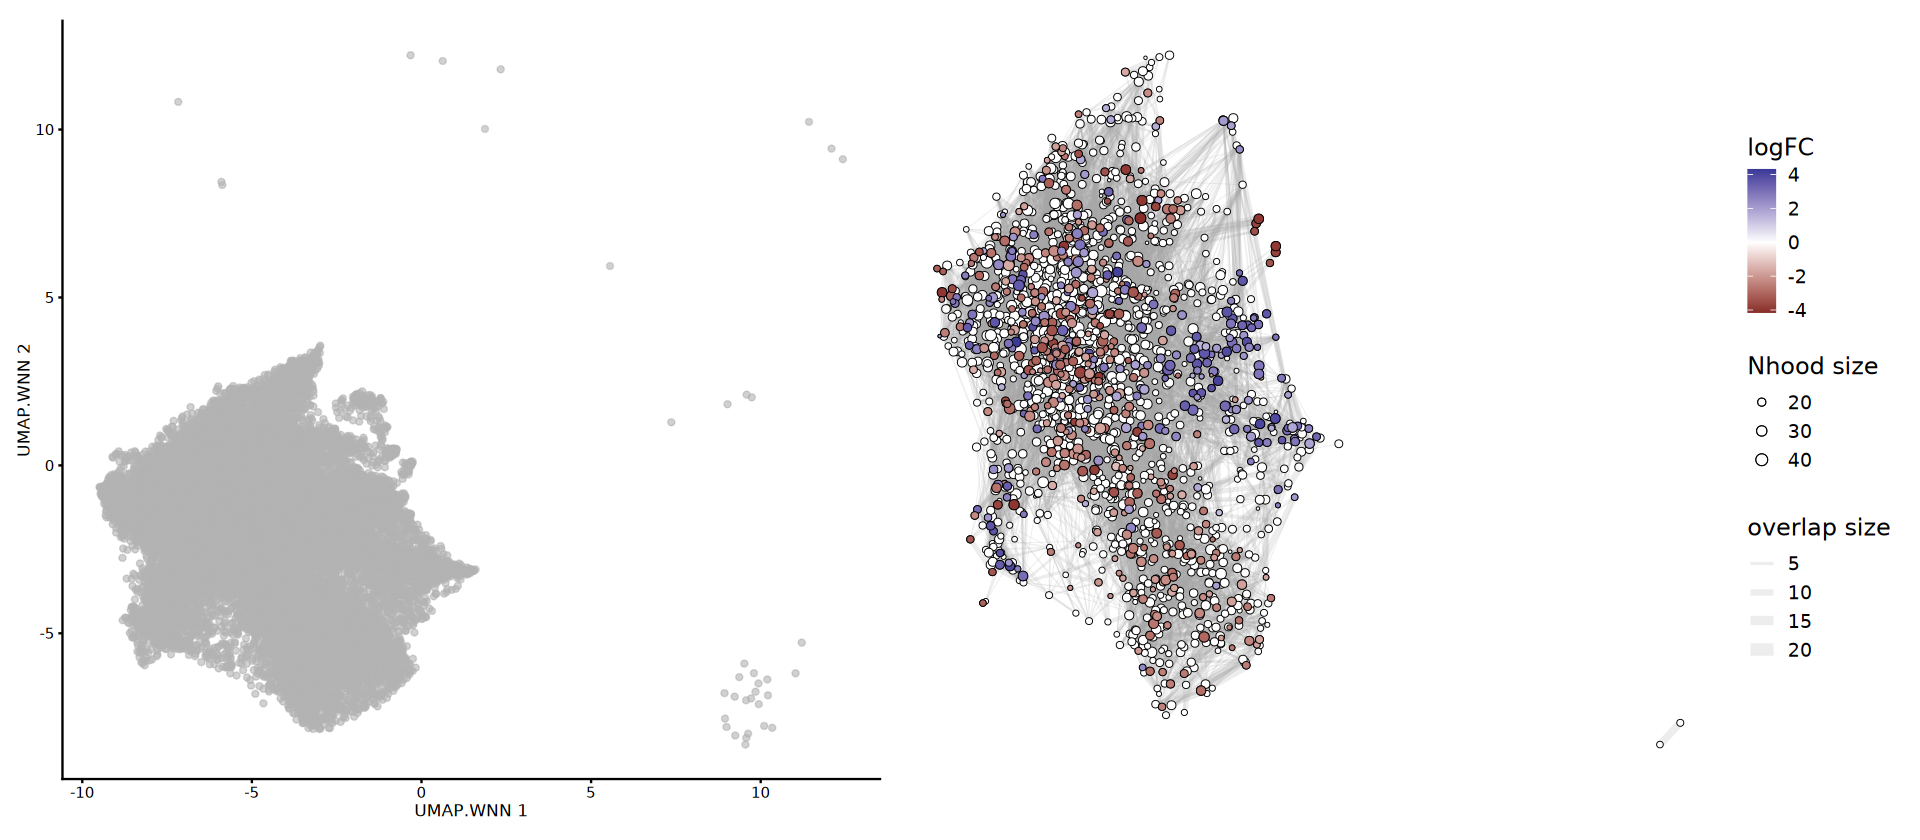

In [38]:
options(repr.plot.width=16)
adata_milo <- buildNhoodGraph(adata_milo)

plotUMAP(adata_milo, dimred = 'UMAP.WNN') + plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.WNN") +
  plot_layout(guides="collect")

In [21]:
reducedDims(adata_milo)

List of length 7
names(7): PCA HARMONY.RNA UMAP.RNA LSI HARMONY.ATAC UMAP.ATAC UMAP.WNN

Adding nhood effect sizes to neighbourhood graph attributes



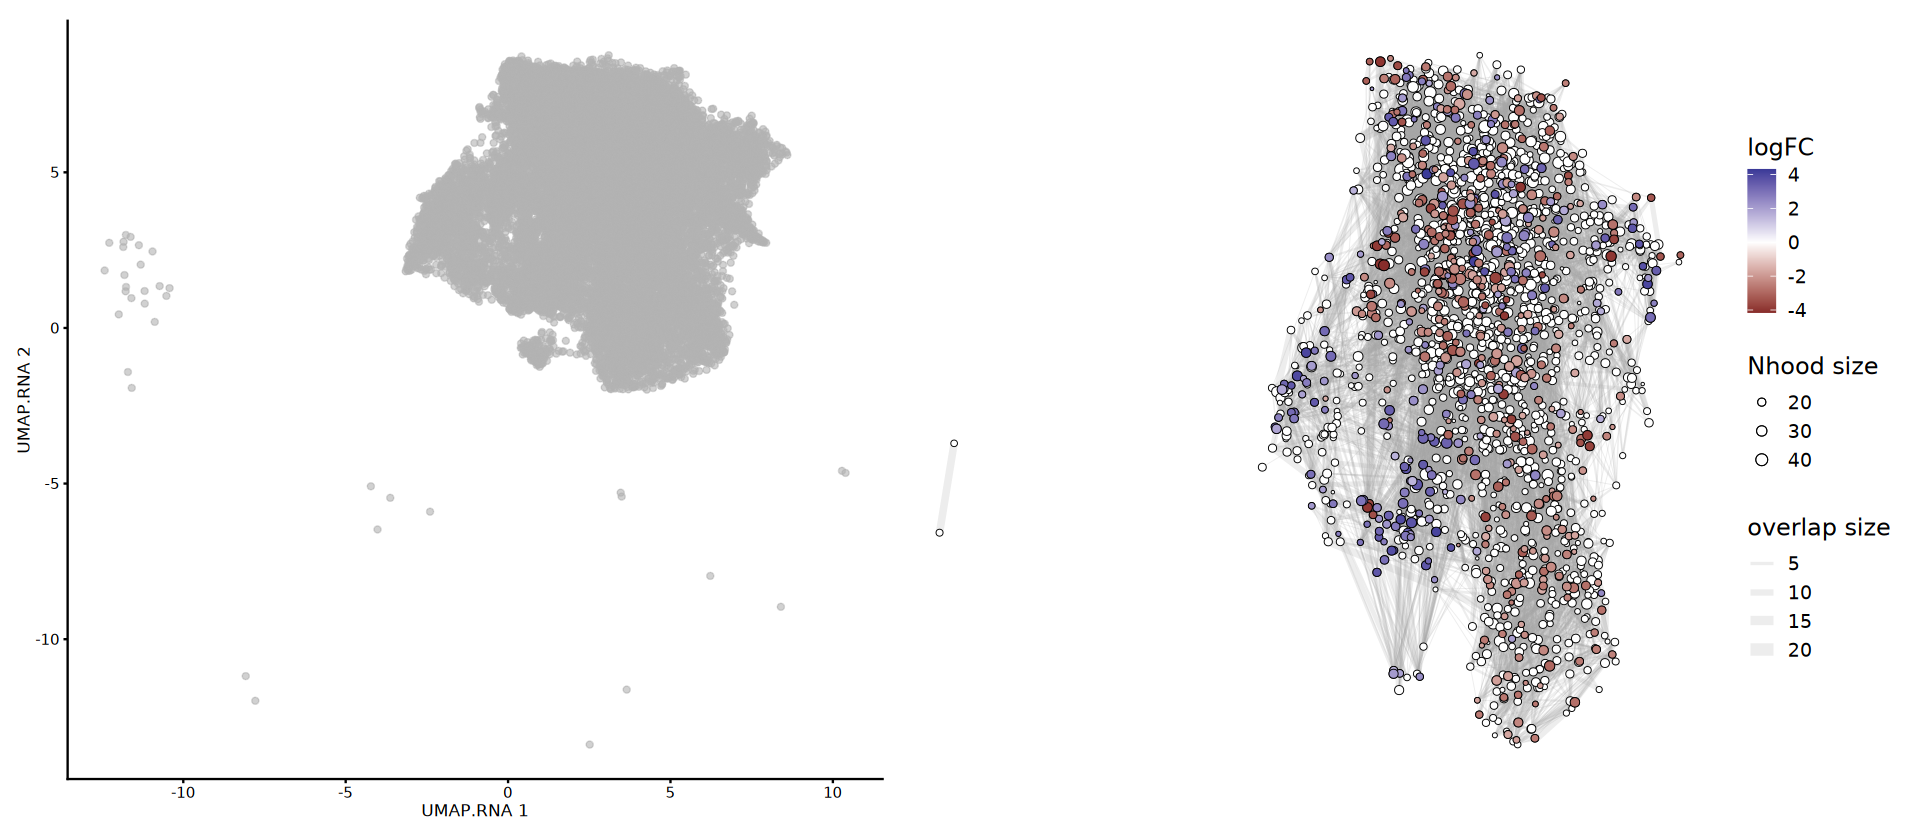

In [39]:
options(repr.plot.width=16)
adata_milo <- buildNhoodGraph(adata_milo)

plotUMAP(adata_milo, dimred = 'UMAP.RNA') + plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.RNA") +
  plot_layout(guides="collect")

Adding nhood effect sizes to neighbourhood graph attributes

Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”


agg_record_4e9226e955dbd 
                       2

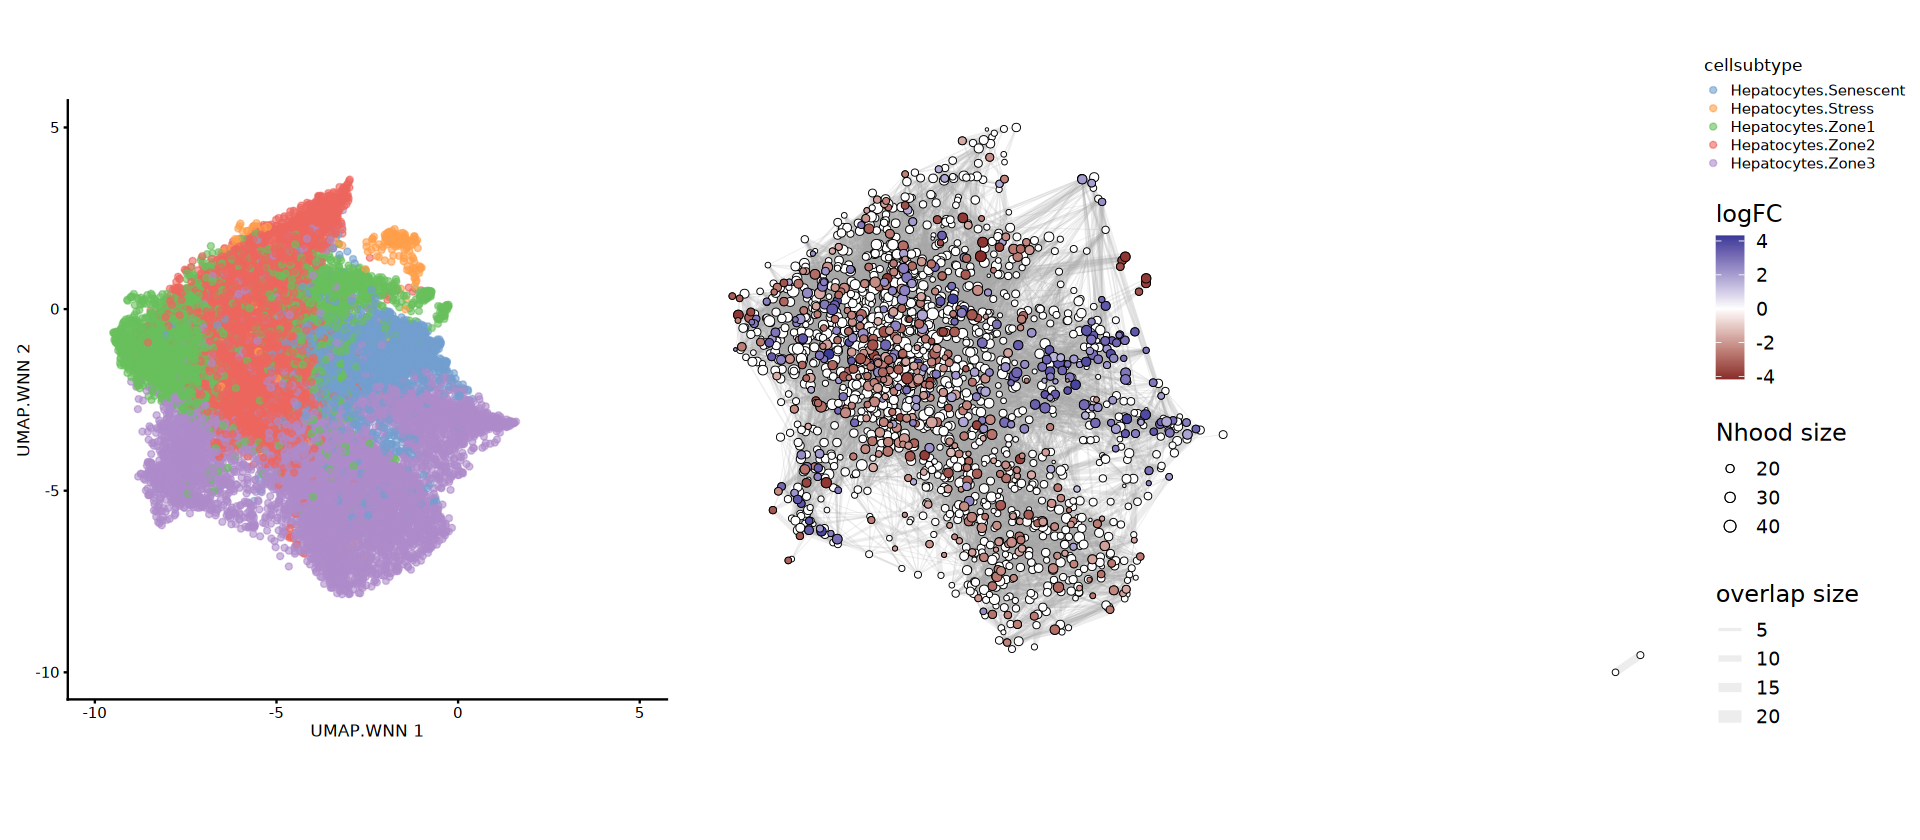

In [40]:
p1 <- plotUMAP(adata_milo, dimred = 'UMAP.WNN', colour_by='cellsubtype') +
  theme(aspect.ratio = 1) + xlim(c(-10,5)) + ylim(c(-10,5))
p2 <- plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.WNN") +
  theme(aspect.ratio = 0.6)

p1 + p2 + plot_layout(guides = "collect")

pdf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_vs_Neighborhoods_condition.pdf', width=16)
p1 + p2 + plot_layout(guides = "collect")
dev.off()

Adding nhood effect sizes to neighbourhood graph attributes

Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 37 rows containing missing values or values outside the scale range
(`geom_point()`).”


agg_record_4e92227c1994c 
                       2

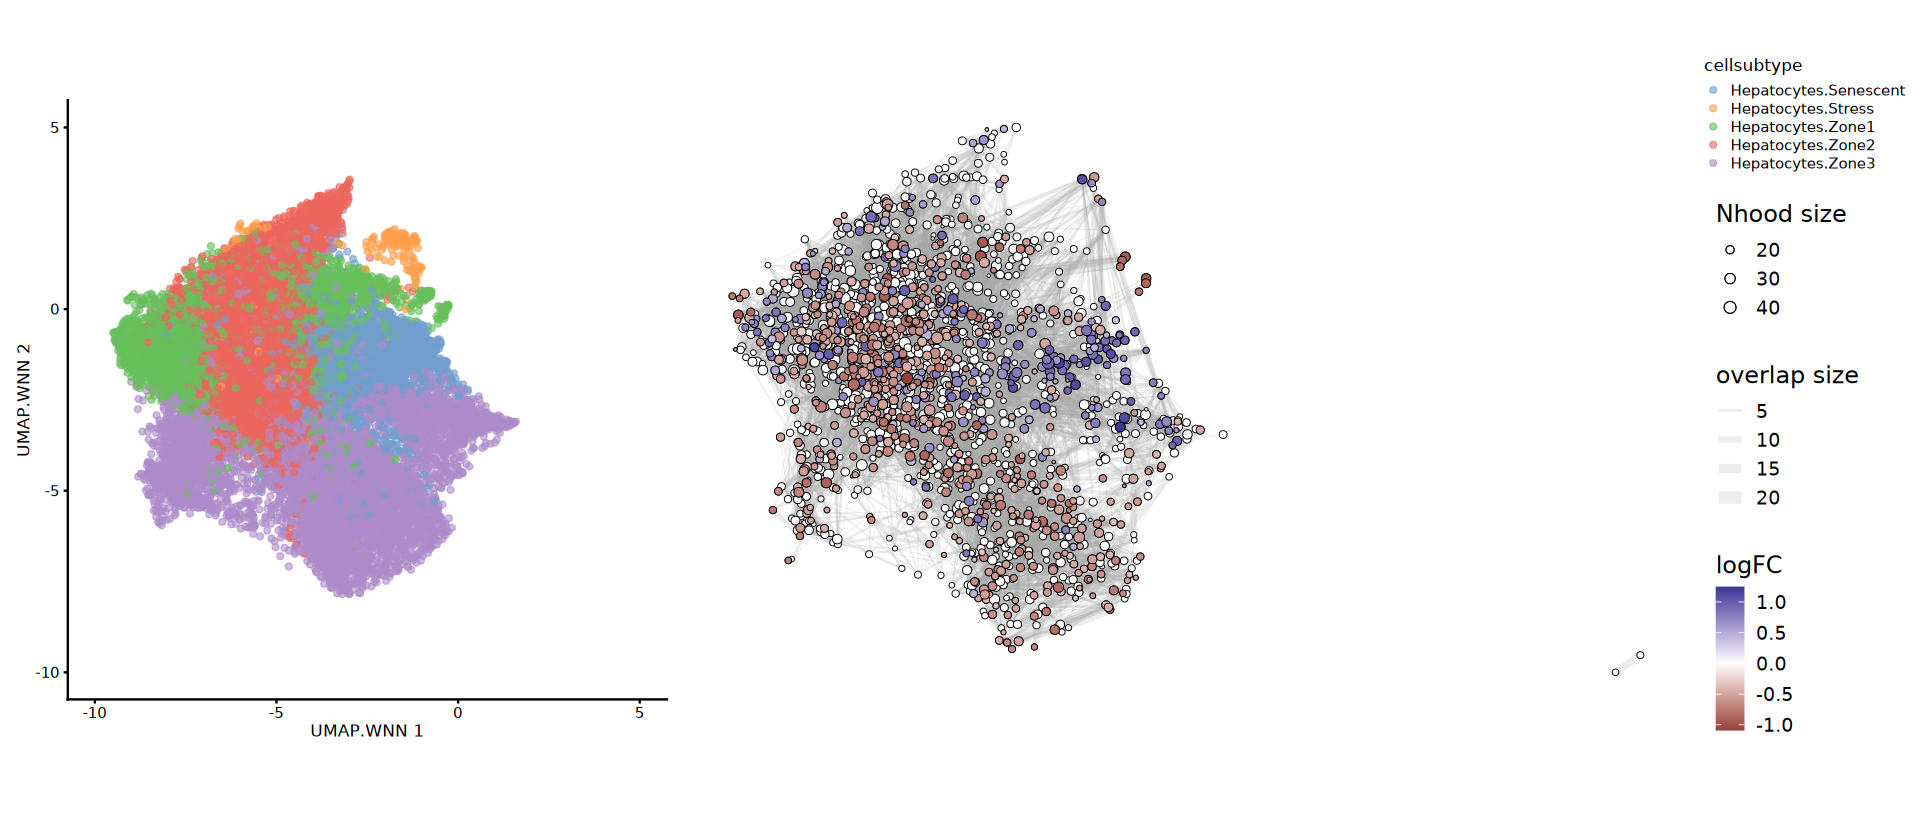

In [23]:
p1 <- plotUMAP(adata_milo, dimred = 'UMAP.WNN', colour_by='cellsubtype') +
  theme(aspect.ratio = 1) + xlim(c(-10,5)) + ylim(c(-10,5))
p2 <- plotNhoodGraphDA(adata_milo, da_results, alpha=0.05, layout = "UMAP.WNN") +
  theme(aspect.ratio = 0.6)

p1 + p2 + plot_layout(guides = "collect")

pdf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_vs_Neighborhoods_fibrosis.pdf', width=16)
p1 + p2 + plot_layout(guides = "collect")
dev.off()

In [41]:
da_results <- annotateNhoods(adata_milo, da_results, 'cellsubtype')
dim(da_results)
head(da_results)

Converting cellsubtype to factor...



[1] 1908    9

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cellsubtype,cellsubtype_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,1.1016521,12.18821,3.4343062,0.1496863314,0.271111839,1,0.276503263,Hepatocytes.Zone2,0.6250000
2,-3.9067164,12.37818,14.7639980,0.0001218877,0.001576577,2,0.001932647,Hepatocytes.Zone1,0.9600000
3,-3.2500049,12.26194,14.6844334,0.0001271413,0.001576577,3,0.001932647,Hepatocytes.Zone2,0.5384615
4,0.3322194,12.31653,0.1575268,0.8579498771,0.973806308,4,0.972150512,Hepatocytes.Zone2,0.9375000
5,-0.5131831,12.30080,0.3363235,0.5619599270,0.717683762,5,0.721698874,Hepatocytes.Zone2,0.9285714
6,-2.6710903,12.23447,13.2385076,0.0002743443,0.002119227,6,0.002412676,Hepatocytes.Zone2,0.9090909


Converting group_by to factor...



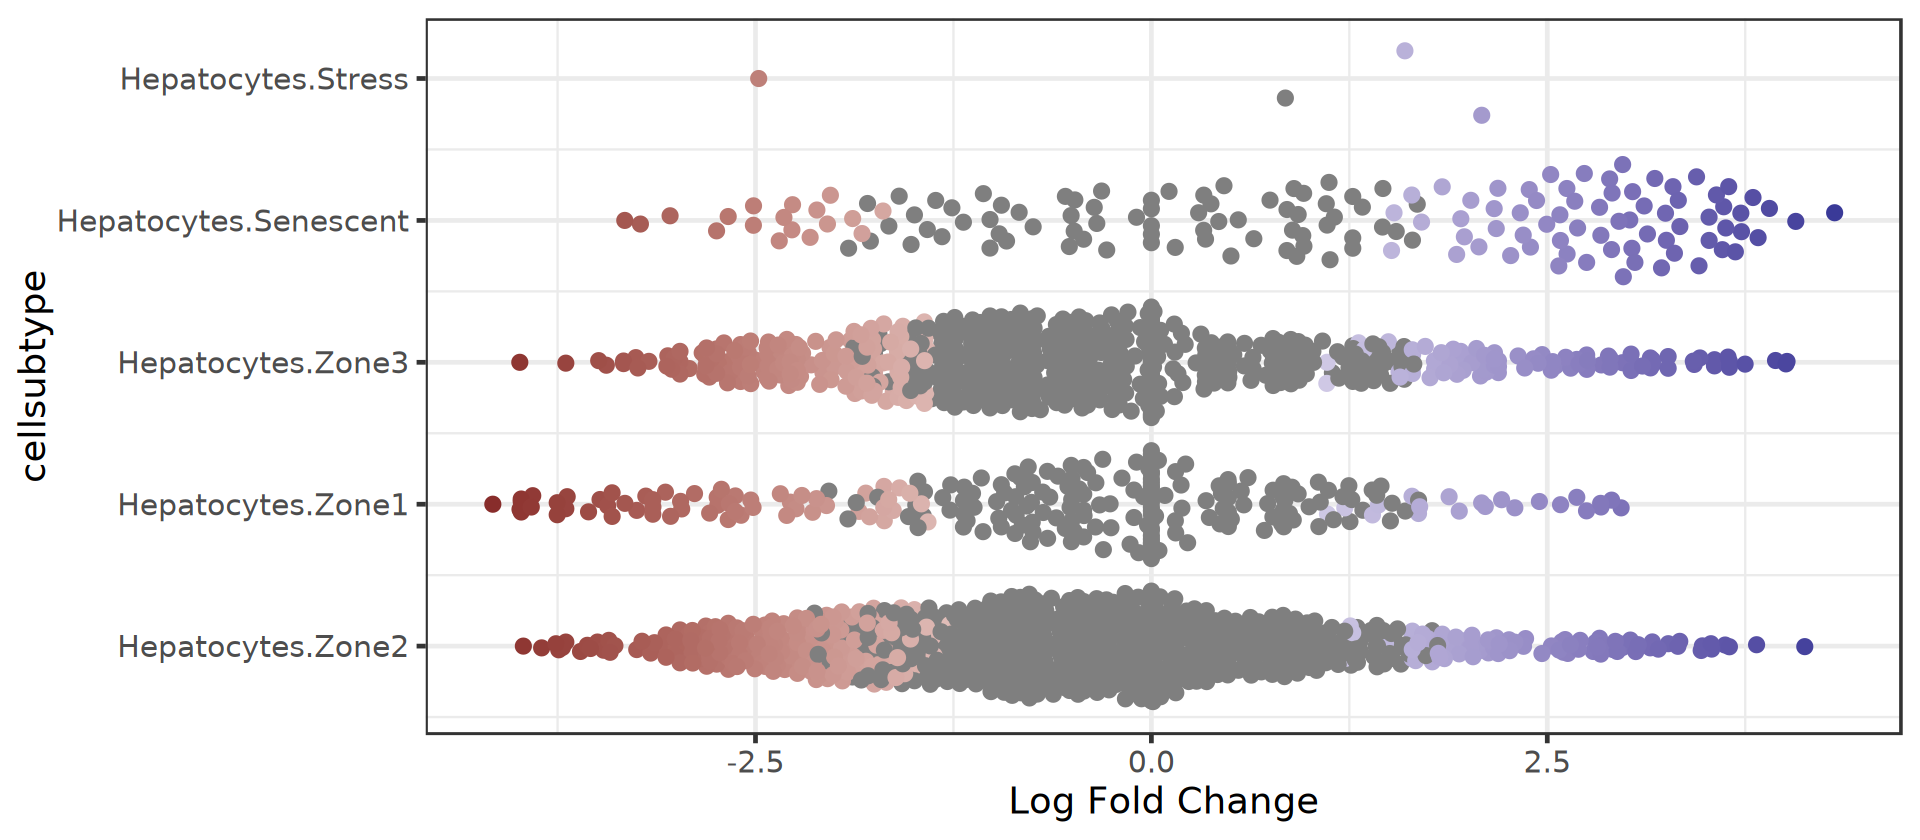

In [42]:
plotDAbeeswarm(da_results, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

In [44]:
write.table(da_results, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_condition.tsv', sep='\t', col.names=T, row.names=F, quote=F)

In [2]:
adata_milo <- readRDS('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes.RDS')

In [ ]:
da_results <- testNhoods(adata_milo, design = ~ Fibrosis.stage, design.df = fibrosis_design)
da_results <- testNhoods(adata_milo, design = ~ condition, design.df = condition_design)

In [3]:
condition_design <- data.frame(colData(adata_milo))[,c("donor_demux", "condition")] %>%
    mutate(condition=factor(condition, levels=c('Control','MASL','MASH','MetALD')))
condition_design <- distinct(condition_design)
rownames(condition_design) <- condition_design$donor_demux
## Reorder rownames to match columns of nhoodCounts(milo)
condition_design <- condition_design[colnames(nhoodCounts(adata_milo)), , drop=FALSE]

condition_design

,donor_demux,condition
,<chr>,<fct>
HL200707,HL200707,MASL
HL160029,HL160029,Control
HL170049,HL170049,MetALD
HL200805,HL200805,Control
HL210726,HL210726,MASH
HL170060,HL170060,MetALD
HL230316,HL230316,Control
HL210120,HL210120,MetALD
HL160042,HL160042,MASL


In [4]:
da_results_paired <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = condition_design,
  model.contrasts = c("conditionMASL", "conditionMASH", "conditionMetALD")
)

da_results_paired

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with k-distance weighting



,logFC.conditionMASL,logFC.conditionMASH,logFC.conditionMetALD,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.4590170,0.7798253,1.10165214,12.18821,2.3037426,1.357556e-01,1.551027e-01,1,1.573502e-01
2,-3.9067164,-3.9067164,-3.90671641,12.37818,20.4782007,2.918983e-13,5.986765e-11,2,8.099477e-11
3,-3.2500049,-2.7890963,-3.25000493,12.26194,15.9985497,2.141575e-10,5.837321e-09,3,6.892448e-09
4,0.8507386,1.4930697,0.33221941,12.31653,1.3135578,2.679461e-01,2.929749e-01,4,2.959150e-01
5,0.7646128,-0.7234838,-0.51318312,12.30080,1.4225350,2.339843e-01,2.585072e-01,5,2.611994e-01
6,-2.6710903,-0.8282291,-2.67109026,12.23447,11.6825477,3.787449e-07,2.223524e-06,6,2.528667e-06
7,1.2599457,-1.5361253,-0.64194004,12.24399,8.5878292,1.089176e-05,3.724279e-05,7,4.081042e-05
8,0.7434730,2.2055068,1.91982862,12.25112,4.3596004,4.470308e-03,6.991269e-03,8,7.241975e-03
9,1.0546708,1.2848038,1.26832960,12.17042,2.3363000,1.964649e-01,2.192135e-01,9,2.217103e-01


In [6]:
da_results_paired <- annotateNhoods(adata_milo, da_results_paired, 'cellsubtype')


Converting cellsubtype to factor...



In [7]:
plotDAbeeswarm(da_results_paired, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL, ==)

Converting group_by to factor...



ERROR: [1m[33mError[39m in `geom_quasirandom()`:[22m
[1m[22m[33m![39m Problem while computing aesthetics.
[36mℹ[39m Error occurred in the 1st layer.
[1mCaused by error:[22m
[33m![39m object 'logFC' not found


In [8]:
da_results_MASH <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = condition_design,
  model.contrasts = "conditionMASH",
  fdr.weighting = "graph-overlap"
)

da_results_MASH

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with graph-overlap weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.7798253,12.18821,2.63936186,2.016937e-01,3.206930e-01,1,3.169312e-01
2,-3.9067164,12.37818,26.19337833,3.092442e-07,1.940858e-05,2,2.205638e-05
3,-2.7890963,12.26194,13.68611617,2.161197e-04,1.412180e-03,3,1.293355e-03
4,1.4930697,12.31653,3.54417093,5.975688e-02,1.252924e-01,4,1.201141e-01
5,-0.7234838,12.30080,1.05492280,3.043776e-01,4.317863e-01,5,4.274425e-01
6,-0.8282291,12.23447,1.19133505,2.750621e-01,3.940079e-01,6,3.887348e-01
7,-1.5361253,12.24399,14.28133691,6.298503e-03,1.919736e-02,7,1.788418e-02
8,2.2055068,12.25112,10.92364790,9.496581e-04,4.564100e-03,8,4.104317e-03
9,1.2848038,12.17042,6.15550480,6.274790e-02,1.297107e-01,9,1.249253e-01


Converting cellsubtype to factor...

Converting group_by to factor...



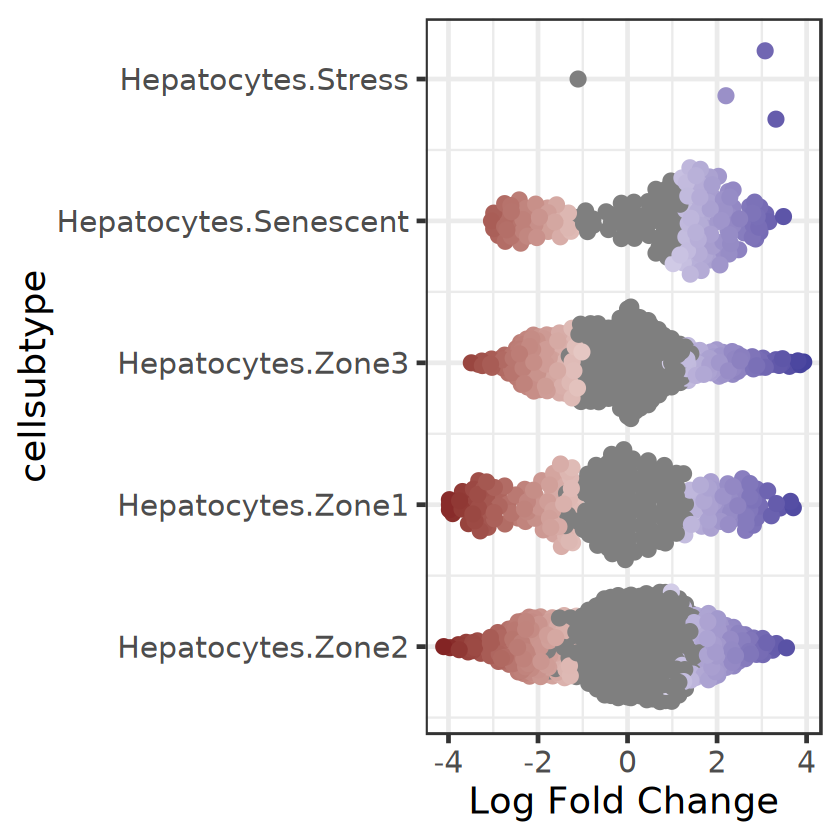

In [10]:
da_results_MASH <- annotateNhoods(adata_milo, da_results_MASH, 'cellsubtype')
plotDAbeeswarm(da_results_MASH, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with graph-overlap weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.10165214,12.18821,3.43430616,0.1496863314,0.271111839,1,0.262830813
2,-3.90671641,12.37818,14.76399801,0.0001218877,0.001576577,2,0.001489296
3,-3.25000493,12.26194,14.68443342,0.0001271413,0.001576577,3,0.001489296
4,0.33221941,12.31653,0.15752676,0.8579498771,0.973806308,4,0.982542483
5,-0.51318312,12.30080,0.33632350,0.5619599270,0.717683762,5,0.714097040
6,-2.67109026,12.23447,13.23850759,0.0002743443,0.002119227,6,0.002082629
7,-0.64194004,12.24399,0.80004517,0.3710812422,0.503257669,7,0.498440237
8,1.91982862,12.25112,7.40738713,0.0271800710,0.076829001,8,0.075453316
9,1.26832960,12.17042,4.92285693,0.0641744930,0.149871412,9,0.142422275


Converting cellsubtype to factor...

Converting group_by to factor...



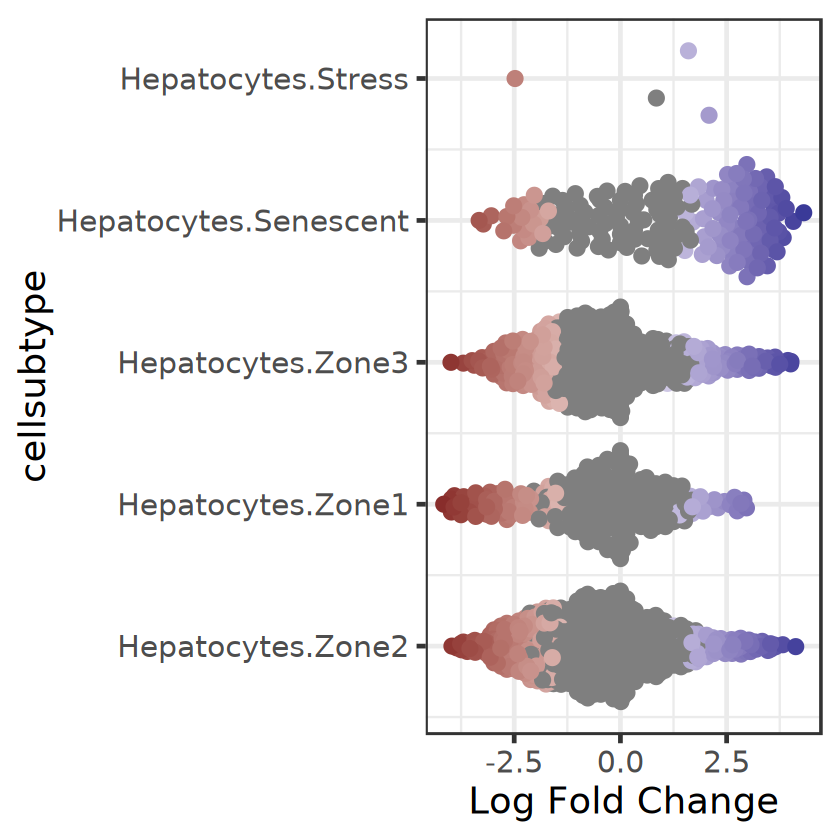

In [11]:
da_results_MetALD <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = condition_design,
  model.contrasts = "conditionMetALD",
  fdr.weighting = "graph-overlap"
)

da_results_MetALD

da_results_MetALD <- annotateNhoods(adata_milo, da_results_MetALD, 'cellsubtype')
plotDAbeeswarm(da_results_MetALD, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with graph-overlap weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.4590170,12.18821,6.73538440,1.975995e-02,5.409180e-02,1,5.216559e-02
2,-3.9067164,12.37818,27.98720227,1.222841e-07,1.054154e-05,2,1.055003e-05
3,-3.2500049,12.26194,27.44680279,1.616841e-07,1.054154e-05,3,1.055003e-05
4,0.8507386,12.31653,1.35291490,2.447709e-01,3.760249e-01,4,3.744940e-01
5,0.7646128,12.30080,0.90612008,3.411474e-01,4.786098e-01,5,4.765729e-01
6,-2.6710903,12.23447,24.35376005,9.406050e-07,2.136517e-05,6,2.270040e-05
7,1.2599457,12.24399,2.85553172,9.106212e-02,1.782016e-01,7,1.737138e-01
8,0.7434730,12.25112,2.38539368,2.054231e-01,3.352843e-01,8,3.313669e-01
9,1.0546708,12.17042,4.79653172,6.448684e-02,1.362579e-01,9,1.310747e-01


Converting cellsubtype to factor...

Converting group_by to factor...



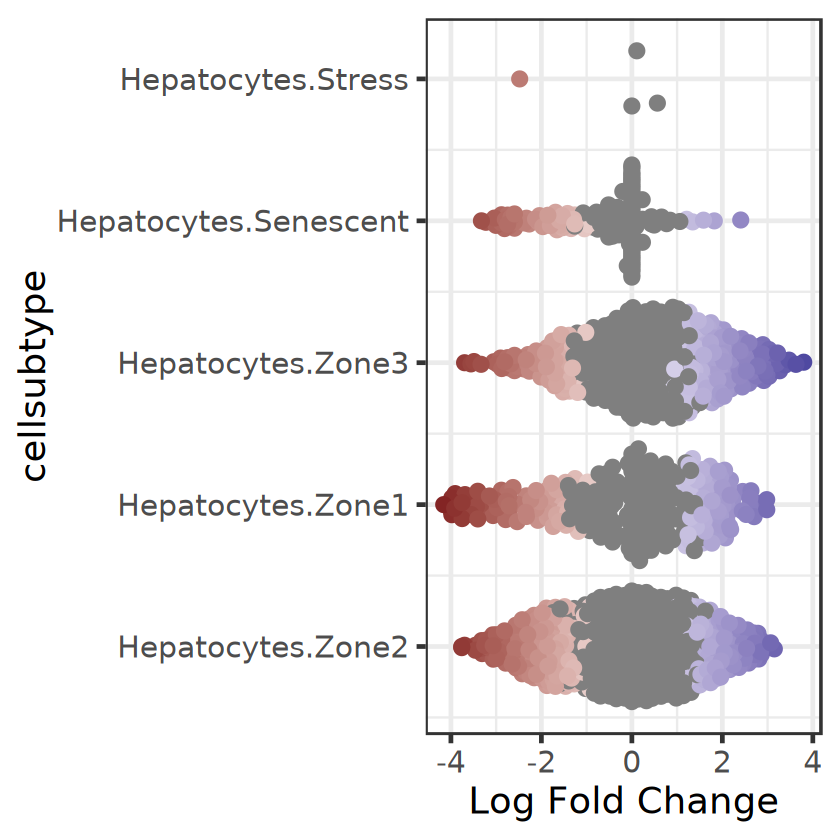

In [12]:
da_results_MASL <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = condition_design,
  model.contrasts = "conditionMASL",
  fdr.weighting = "graph-overlap"
)

da_results_MASL

da_results_MASL <- annotateNhoods(adata_milo, da_results_MASL, 'cellsubtype')
plotDAbeeswarm(da_results_MASL, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

In [16]:
da_results_MASL %>%
    filter(FDR < 0.1) %>%
    mutate(direction=ifelse(logFC > 0, 'Up', 'Down')) %>%
    select(direction, cellsubtype) %>% table()

         cellsubtype
direction Hepatocytes.Senescent Hepatocytes.Stress Hepatocytes.Zone1
     Down                    48                  1                61
     Up                       5                  0                61
         cellsubtype
direction Hepatocytes.Zone2 Hepatocytes.Zone3
     Down               222                92
     Up                 164               174

In [18]:
da_results_MASH %>%
    filter(FDR < 0.1) %>%
    mutate(direction=ifelse(logFC > 0, 'Up', 'Down')) %>%
    select(direction, cellsubtype) %>% table()

         cellsubtype
direction Hepatocytes.Senescent Hepatocytes.Stress Hepatocytes.Zone1
     Down                    36                  0                74
     Up                      74                  3                51
         cellsubtype
direction Hepatocytes.Zone2 Hepatocytes.Zone3
     Down               198               168
     Up                 158                92

In [17]:
da_results_MetALD %>%
    filter(FDR < 0.1) %>%
    mutate(direction=ifelse(logFC > 0, 'Up', 'Down')) %>%
    select(direction, cellsubtype) %>% table()

         cellsubtype
direction Hepatocytes.Senescent Hepatocytes.Stress Hepatocytes.Zone1
     Down                    18                  1                58
     Up                      69                  2                21
         cellsubtype
direction Hepatocytes.Zone2 Hepatocytes.Zone3
     Down               202               144
     Up                  87                82

In [28]:
colData(adata_milo)$Fibrosis.stage

[1] 0 0 0 4 0 4 4 2 2 0 0 0 4 3 0 2 0 0 0 4 4 4 2 0 0 3 1 0 1 2 4 0 0 2 2 2
   [37] 1 3 4 2 1 0 0 4 1 1 2 0 0 2 0 1 1 4 0 0 2 1 0 4 4 4 0 0 2 0 4 4 2 3 1 4
   [73] 3 4 2 2 0 1 0 4 1 4 0 0 0 4 4 3 4 0 0 0 0 2 0 3 0 2 0 2 0 3 0 0 4 0 1 0
  [109] 0 4 2 0 4 1 1 0 0 0 0 2 4 4 2 0 0 1 3 0 2 0 3 0 2 4 2 0 0 4 0 0 3 0 4 4
  [145] 4 2 2 1 0 0 0 1 0 0 0 1 2 4 0 0 0 0 0 0 0 3 0 3 0 0 0 0 0 4 2 1 0 0 0 4
  [181] 0 0 4 4 1 4 2 2 0 2 4 4 3 0 0 1 2 2 0 0 0 2 2 0 1 0 4 1 0 0 0 4 1 0 2 2
  [217] 0 0 1 0 0 0 0 3 0 3 0 2 3 3 1 0 0 4 2 0 2 0 4 0 0 4 0 2 0 2 4 0 1 2 0 0
  [253] 2 0 4 0 0 1 4 0 4 0 0 0 1 0 4 2 4 1 0 4 0 1 0 3 0 0 1 2 3 4 0 1 0 1 2 0
  [289] 2 0 0 0 2 0 1 4 4 2 0 4 0 0 0 4 3 2 0 0 1 2 4 0 4 0 4 4 2 3 0 2 0 0 0 4
  [325] 1 0 1 2 0 0 0 0 0 0 0 1 0 2 0 3 0 1 0 4 1 1 2 4 0 4 1 1 4 1 0 0 0 0 2 0
  [361] 0 0 4 0 0 0 4 0 1 0 0 1 3 0 2 0 3 0 1 0 0 0 1 2 0 4 1 0 0 0 4 1 0 4 4 4
  [397] 4 3 0 0 3 0 0 0 1 0 0 0 0 2 0 3 0 0 4 1 0 0 0 2 0 0 3 4 0 0 2 3 0 0 0 0
  [433] 0 0 1 4 0 0 0 2 1 0 4 0 2 2 4 1 0 0 0 2 0 4 1 3 4 0 0 0 0 0 1 3 1 4 2 0
  [469] 0 0 2 0 0 0 0 4 0 0 0 0 0 0 4 3 0 0 2 0 2 4 3 4 0 0 0 0 1 0 3 0 3 0 2 0
  [505] 0 0 0 0 2 0 0 2 0 0 3 0 0 4 0 4 4 4 0 0 1 2 2 4 2 2 0 0 0 0 1 4 0 0 0 0
  [541] 2 0 0 3 4 3 0 0 0 1 2 3 0 0 0 0 3 0 0 0 2 0 0 0 4 1 4 1 0 4 0 1 0 2 2 0
  [577] 0 4 0 3 0 0 2 0 1 0 2 3 0 1 2 1 1 2 0 1 1 4 0 0 4 1 2 4 4 0 0 0 0 4 1 3
  [613] 0 3 0 0 0 4 2 0 4 0 2 3 2 4 3 0 0 0 4 2 4 4 0 2 2 1 4 2 4 0 0 0 1 0 2 0
  [649] 1 0 0 4 0 1 0 1 4 4 0 0 0 3 0 1 4 0 0 4 1 4 4 1 4 0 0 0 0 0 4 0 4 0 0 2
  [685] 0 0 0 2 0 0 3 0 0 0 0 2 0 0 2 2 4 0 2 4 0 4 0 0 1 0 4 0 4 2 3 0 3 0 0 2
  [721] 0 0 4 2 4 0 0 1 0 4 4 2 4 0 4 4 0 1 2 1 3 0 1 1 1 2 0 4 3 2 0 0 0 3 1 0
  [757] 1 0 1 0 2 0 0 0 4 1 0 4 0 3 0 4 1 0 0 3 1 2 0 0 3 0 0 0 1 4 4 2 0 1 4 0
  [793] 3 2 4 3 4 2 4 4 0 0 2 4 0 4 3 4 0 0 0 4 0 4 2 0 2 0 2 0 0 1 0 0 4 0 0 2
  [829] 1 0 1 1 2 4 4 0 3 3 0 0 0 4 0 1 4 0 0 0 4 0 0 0 0 4 1 0 4 4 2 0 0 1 2 4
  [865] 1 0 2 1 0 0 0 1 2 0 0 0 0 0 4 0 0 4 3 1 4 1 1 4 1 4 1 1 1 0 0 3 4 0 1 0
  [901] 0 1 1 3 2 0 0 2 4 0 0 4 4 2 1 4 4 3 0 3 0 1 0 0 1 4 2 1 4 2 0 2 2 0 0 0
  [937] 4 0 4 0 1 1 0 2 0 1 4 0 0 2 0 1 4 3 0 1 1 2 4 0 4 1 0 0 1 3 2 2 0 1 3 0
  [973] 0 4 2 4 0 0 0 1 4 0 4 0 0 0 0 4 4 0 4 4 3 0 4 2 4 4 1 0 0 1 1 2 2 4 4 1
 [1009] 4 4 0 2 4 0 0 2 1 4 4 1 4 0 4 1 4 0 4 2 0 1 4 0 4 3 3 0 2 0 2 4 0 1 2 0
 [1045] 3 3 1 4 0 4 0 0 0 2 4 3 3 4 0 4 0 0 0 0 0 4 2 1 1 0 1 0 4 1 3 0 1 0 4 0
 [1081] 0 2 0 1 0 2 2 0 1 3 0 0 0 2 0 0 0 0 4 1 3 1 1 1 0 0 1 2 0 2 0 4 1 1 2 0
 [1117] 0 4 0 1 0 2 0 0 0 0 0 4 4 4 1 0 4 4 1 4 0 0 1 3 0 1 0 0 1 3 3 4 4 0 0 0
 [1153] 2 0 3 0 0 1 1 2 4 4 0 0 0 4 4 0 0 0 4 0 0 4 4 1 0 3 2 4 0 2 0 0 1 0 3 3
 [1189] 0 4 0 1 0 2 4 0 0 0 1 3 4 1 0 0 0 0 1 0 1 1 0 2 4 1 2 0 0 0 0 0 4 0 0 4
 [1225] 0 1 0 1 1 0 0 2 2 0 0 1 1 2 4 0 4 0 3 2 0 0 0 0 0 1 4 0 2 2 0 0 0 0 0 4
 [1261] 3 2 0 0 4 4 0 3 0 3 0 2 0 0 1 0 0 1 1 4 2 4 2 1 2 0 1 0 0 0 0 2 4 3 2 0
 [1297] 1 4 4 0 2 0 0 0 0 0 0 0 0 2 0 1 3 0 1 4 4 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0
 [1333] 4 0 2 0 4 0 0 0 2 1 0 3 3 4 0 2 0 4 3 4 4 0 4 0 0 0 2 4 4 0 1 1 0 0 2 2
 [1369] 4 0 4 0 2 4 0 0 2 1 4 1 2 0 0 2 1 3 0 1 2 1 0 3 2 3 4 3 0 4 0 0 2 4 2 0
 [1405] 2 3 4 4 0 2 3 0 0 0 0 1 4 1 4 4 0 1 0 4 2 1 2 0 2 0 0 2 4 1 2 2 4 1 1 0
 [1441] 1 4 4 0 0 0 0 2 1 0 4 0 0 0 2 1 4 1 1 2 0 0 4 3 0 3 1 0 2 0 0 4 0 1 1 4
 [1477] 0 1 2 1 1 0 1 4 0 2 1 1 4 4 0 0 4 4 4 1 4 0 0 4 0 0 0 0 0 0 4 0 0 0 0 4
 [1513] 0 0 4 0 0 0 0 4 4 1 0 0 0 0 2 0 0 0 0 2 0 0 0 0 2 0 0 1 0 0 4 4 0 3 2 0
 [1549] 4 2 2 0 4 0 1 0 2 0 4 3 0 4 0 4 0 0 4 1 0 2 2 3 3 4 0 2 0 0 4 0 4 0 4 2
 [1585] 4 1 0 0 2 1 4 0 2 1 4 4 3 1 0 4 0 0 1 2 0 4 0 1 2 2 0 4 4 4 0 0 0 0 2 0
 [1621] 4 3 4 4 4 4 2 2 4 0 2 0 0 1 0 1 4 0 2 0 2 3 0 3 0 3 0 3 4 0 0 0 0 0 1 2
 [1657] 4 4 1 0 0 2 1 0 1 1 0 0 0 1 2 0 2 1 4 3 1 0 0 0 0 1 2 0 2 0 0 0 0 0 0 0
 [1693] 3 4 0 0 4 0 0 0 0 4 1 2 0 4 0 4 0 0 0 0 1 3 3 1 2 1 1 4 0 0 0 4 4 4 0 0
 [1729] 4 0 0 4 0 0 0 4 4 1 4 0 4 3 0 0 0 0 0 4 4 2 3 0 0 2 0 1 4 2 0 0 0 0 0 1
 [1765] 1 0 2 4 0 4 4 0 0 4 4 1 0 0 0 2 0 2 1 4 4 2 2 0 0 3 4 0 0 0 4 1 2 1 3 2
 [18

In [30]:
condition_fib_vect <- ifelse(colData(adata_milo)$condition=='Control', 'Control',
                                            ifelse(colData(adata_milo)$condition=='MASL','MASL',
                                            ifelse(colData(adata_milo)$Fibrosis.stage <= 2, 'Low_Fib', 'High_Fib')))

table(colData(adata_milo)$condition, condition_fib_vect)

         condition_fib_vect
          Control High_Fib Low_Fib MASL
  Control    6500        0       0    0
  MASH          0     2000    3750    0
  MASL          0        0       0 6250
  MetALD        0     2000    1000    0

In [31]:
colData(adata_milo)$condition_fib <- condition_fib_vect

In [33]:
fib_cond_design <- data.frame(colData(adata_milo))[,c("donor_demux", "condition_fib")] %>%
    mutate(condition=factor(condition_fib, levels=c('Control','MASL','Low_Fib','High_Fib')))
fib_cond_design <- distinct(fib_cond_design)
rownames(fib_cond_design) <- fib_cond_design$donor_demux
## Reorder rownames to match columns of nhoodCounts(milo)
fib_cond_design <- fib_cond_design[colnames(nhoodCounts(adata_milo)), , drop=FALSE]

fib_cond_design

,donor_demux,condition_fib,condition
,<chr>,<chr>,<fct>
HL200707,HL200707,MASL,MASL
HL160029,HL160029,Control,Control
HL170049,HL170049,High_Fib,High_Fib
HL200805,HL200805,Control,Control
HL210726,HL210726,High_Fib,High_Fib
HL170060,HL170060,Low_Fib,Low_Fib
HL230316,HL230316,Control,Control
HL210120,HL210120,High_Fib,High_Fib
HL160042,HL160042,MASL,MASL


In [34]:
da_results_Low_Fib <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = fib_cond_design,
  model.contrasts = "conditionLow_Fib",
  fdr.weighting = "graph-overlap"
)

da_results_Low_Fib

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with graph-overlap weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.352997098,12.18820,5.651856e+00,4.255365e-02,0.1092764274,1,1.029307e-01
2,-3.906634016,12.37808,2.226078e+01,2.382245e-06,0.0000782321,2,7.381748e-05
3,-2.711154755,12.26194,1.079795e+01,1.016350e-03,0.0060223498,3,5.092477e-03
4,1.267402630,12.31653,2.503580e+00,1.135898e-01,0.2173815368,4,2.100763e-01
5,-0.911623656,12.30079,1.543429e+00,2.141100e-01,0.3693154565,5,3.593355e-01
6,-1.239435059,12.23448,2.449559e+00,1.175599e-01,0.2238566346,6,2.166453e-01
7,-1.536122106,12.24398,1.231482e+01,9.200342e-03,0.0322688485,7,2.889218e-02
8,2.325354747,12.25112,1.122648e+01,8.065767e-04,0.0050128609,8,4.192878e-03
9,1.477202019,12.17043,7.151119e+00,4.255366e-02,0.1092764274,9,1.029307e-01


Converting cellsubtype to factor...

Converting group_by to factor...



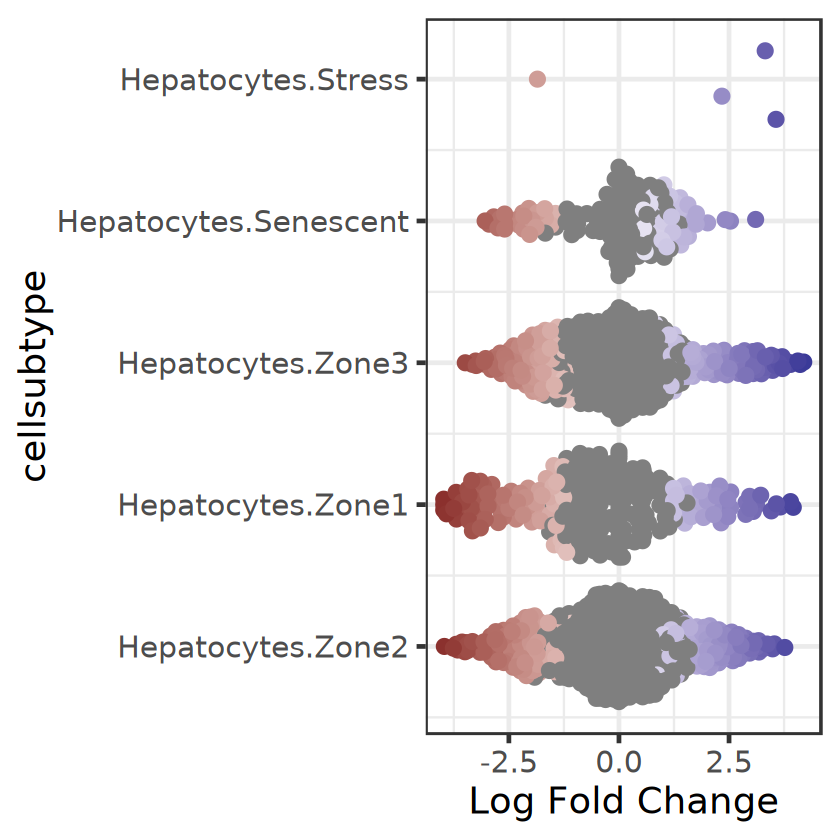

In [35]:
da_results_Low_Fib <- annotateNhoods(adata_milo, da_results_Low_Fib, 'cellsubtype')
plotDAbeeswarm(da_results_Low_Fib, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with graph-overlap weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.07295526,12.18820,0.05387126,8.694346e-01,0.9723806966,1,0.9906665321
2,-3.90663402,12.37808,19.02050179,1.294040e-05,0.0002089759,2,0.0002120286
3,-3.25006789,12.26194,18.72071828,1.514230e-05,0.0002089759,3,0.0002120286
4,1.09102636,12.31653,1.78177198,1.819338e-01,0.2964387269,4,0.2908085932
5,-0.38550860,12.30079,0.22956847,6.318447e-01,0.7792886900,5,0.7842002803
6,-1.25754380,12.23448,2.21463146,1.367097e-01,0.2373449909,6,0.2314077498
7,-0.81623689,12.24398,1.65016921,1.989378e-01,0.3151637372,7,0.3097392516
8,1.81204914,12.25112,7.49605344,2.232049e-02,0.0599823919,8,0.0600932546
9,1.00714504,12.17043,3.91789554,1.007790e-01,0.1952144795,9,0.1909415631


Converting cellsubtype to factor...

Converting group_by to factor...



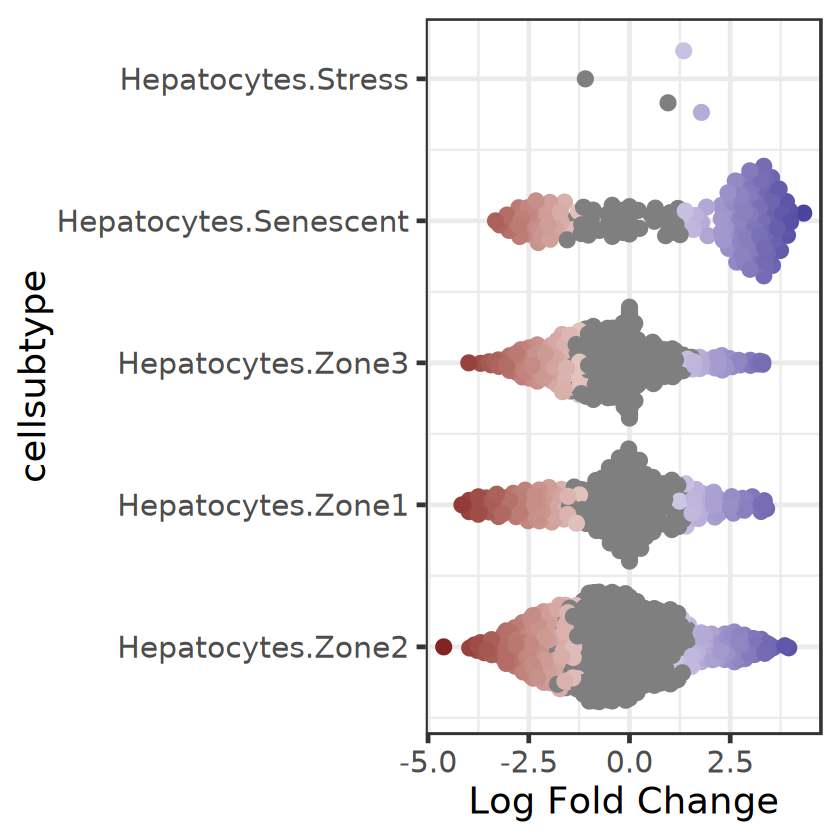

In [36]:
da_results_High_Fib <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = fib_cond_design,
  model.contrasts = "conditionHigh_Fib",
  fdr.weighting = "graph-overlap"
)

da_results_High_Fib

da_results_High_Fib <- annotateNhoods(adata_milo, da_results_High_Fib, 'cellsubtype')
plotDAbeeswarm(da_results_High_Fib, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

Using TMM normalisation

Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Warning message in max(abs(logR)):
“no non-missing arguments to max; returning -Inf”
Running with model contrasts

Renaming (Intercept) to Intercept

Performing spatial FDR correction with graph-overlap weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.4598908,12.18820,6.78613475,1.975995e-02,5.393703e-02,1,5.206177e-02
2,-3.9066340,12.37808,28.06377372,1.175409e-07,1.058108e-05,2,1.066178e-05
3,-3.2500679,12.26194,27.38840270,1.666403e-07,1.058108e-05,3,1.066178e-05
4,0.8506811,12.31653,1.35767990,2.439418e-01,3.747511e-01,4,3.732253e-01
5,0.7645571,12.30079,0.90835239,3.405534e-01,4.774254e-01,5,4.755176e-01
6,-2.6712558,12.23448,24.31084671,9.406050e-07,2.111382e-05,6,2.255258e-05
7,1.2599058,12.24398,2.85874806,9.088020e-02,1.776633e-01,7,1.732421e-01
8,0.7435602,12.25112,2.38133831,2.054231e-01,3.352843e-01,8,3.313669e-01
9,1.0549965,12.17043,4.81355988,6.448684e-02,1.359568e-01,9,1.308572e-01


Converting cellsubtype to factor...

Converting group_by to factor...



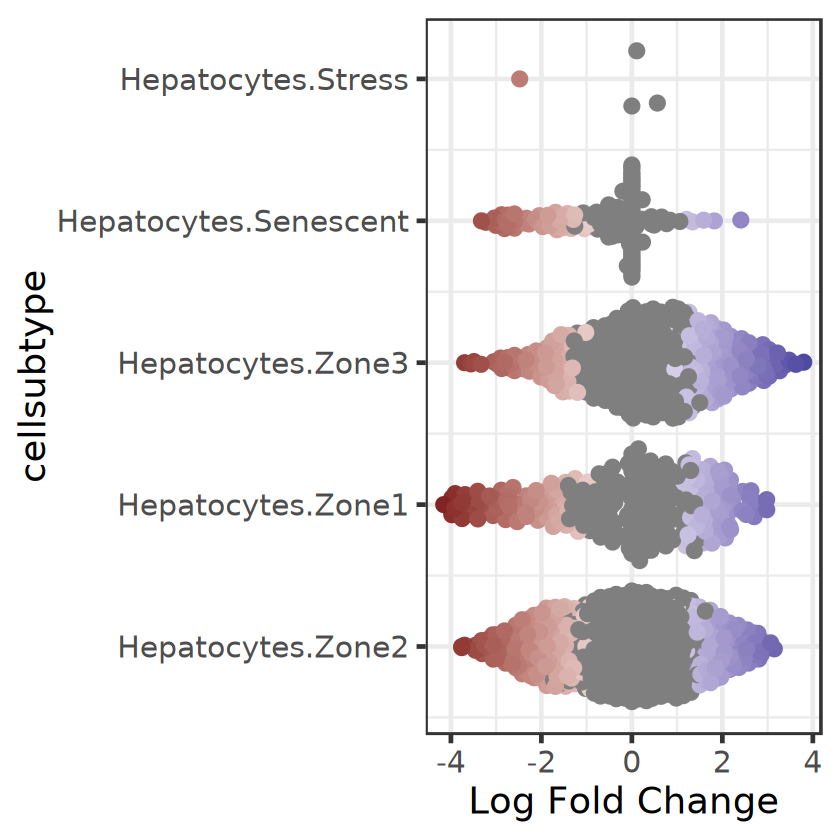

In [37]:
da_results_fib_MASL <- testNhoods(
  adata_milo,
  design = ~ condition,
  design.df = fib_cond_design,
  model.contrasts = "conditionMASL",
  fdr.weighting = "graph-overlap"
)

da_results_fib_MASL

da_results_fib_MASL <- annotateNhoods(adata_milo, da_results_fib_MASL, 'cellsubtype')
plotDAbeeswarm(da_results_fib_MASL, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL)

In [38]:
da_results_fib_MASL %>%
    filter(FDR < 0.1) %>%
    mutate(direction=ifelse(logFC > 0, 'Up', 'Down')) %>%
    select(direction, cellsubtype) %>% table()

         cellsubtype
direction Hepatocytes.Senescent Hepatocytes.Stress Hepatocytes.Zone1
     Down                    49                  1                61
     Up                       5                  0                61
         cellsubtype
direction Hepatocytes.Zone2 Hepatocytes.Zone3
     Down               222                92
     Up                 165               174

In [39]:
da_results_Low_Fib %>%
    filter(FDR < 0.1) %>%
    mutate(direction=ifelse(logFC > 0, 'Up', 'Down')) %>%
    select(direction, cellsubtype) %>% table()

         cellsubtype
direction Hepatocytes.Senescent Hepatocytes.Stress Hepatocytes.Zone1
     Down                    25                  1                70
     Up                      28                  3                36
         cellsubtype
direction Hepatocytes.Zone2 Hepatocytes.Zone3
     Down               171               132
     Up                 124               100

In [40]:
da_results_High_Fib %>%
    filter(FDR < 0.1) %>%
    mutate(direction=ifelse(logFC > 0, 'Up', 'Down')) %>%
    select(direction, cellsubtype) %>% table()

         cellsubtype
direction Hepatocytes.Senescent Hepatocytes.Stress Hepatocytes.Zone1
     Down                    33                  0                62
     Up                      86                  2                41
         cellsubtype
direction Hepatocytes.Zone2 Hepatocytes.Zone3
     Down               240               183
     Up                 108                49

In [42]:
head(da_results_High_Fib)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cellsubtype,cellsubtype_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,0.07295526,12.18820,0.05387126,0.8694346374,0.9723806966,1,0.9906665321,Hepatocytes.Zone2,0.6250000
2,-3.90663402,12.37808,19.02050179,0.0000129404,0.0002089759,2,0.0002120286,Hepatocytes.Zone1,0.9600000
3,-3.25006789,12.26194,18.72071828,0.0000151423,0.0002089759,3,0.0002120286,Hepatocytes.Zone2,0.5384615
4,1.09102636,12.31653,1.78177198,0.1819338308,0.2964387269,4,0.2908085932,Hepatocytes.Zone2,0.9375000
5,-0.38550860,12.30079,0.22956847,0.6318446559,0.7792886900,5,0.7842002803,Hepatocytes.Zone2,0.9285714
6,-1.25754380,12.23448,2.21463146,0.1367097196,0.2373449909,6,0.2314077498,Hepatocytes.Zone2,0.9090909


In [43]:
write.table(da_results_MASL, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_MASL_vs_Control.tsv', col.names=T, row.names=F, quote=F, sep='\t')
write.table(da_results_MASH, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_MASH_vs_Control.tsv', col.names=T, row.names=F, quote=F, sep='\t')
write.table(da_results_MetALD, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_MetALD_vs_Control.tsv', col.names=T, row.names=F, quote=F, sep='\t')
write.table(da_results_High_Fib, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_Fib+MASH_vs_Control.tsv', col.names=T, row.names=F, quote=F, sep='\t')
write.table(da_results_Low_Fib, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_Fib-MASH_vs_Control.tsv', col.names=T, row.names=F, quote=F, sep='\t')

# Replot

In [2]:
fib_results <- read.table('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_fibrosis.tsv', sep='\t', header=T)
fib_results

logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cellsubtype,cellsubtype_fraction
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>
-0.17623288,12.18822,1.15872466,3.021457e-01,4.229532e-01,1,4.345169e-01,Hepatocytes.Zone2,0.6250000
-0.91501963,12.37868,37.65620677,9.418983e-09,1.695417e-07,2,2.206451e-07,Hepatocytes.Zone1,0.9600000
-0.74028068,12.26192,28.12551744,1.441532e-07,1.751875e-06,3,2.137127e-06,Hepatocytes.Zone2,0.5384615
0.09867614,12.31654,0.18200477,7.512910e-01,8.447043e-01,4,8.505761e-01,Hepatocytes.Zone2,0.9375000
-0.31896027,12.30085,2.50878639,1.135719e-01,1.927892e-01,5,1.998519e-01,Hepatocytes.Zone2,0.9285714
-0.11755000,12.23447,0.44374793,5.054933e-01,6.316184e-01,6,6.407325e-01,Hepatocytes.Zone2,0.9090909
-0.57328560,12.24402,12.36385534,4.600586e-04,1.817374e-03,7,2.029563e-03,Hepatocytes.Zone1,0.6363636
0.58401188,12.25112,8.39520410,2.237074e-02,4.974752e-02,8,5.240667e-02,Hepatocytes.Zone2,0.7916667
0.06764430,12.17037,0.19974898,7.226620e-01,8.202493e-01,9,8.269681e-01,Hepatocytes.Zone2,0.6470588


In [3]:
cond_results <- read.table('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_condition.tsv', sep='\t', header=T)
cond_results

logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cellsubtype,cellsubtype_fraction
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>
1.10165214,12.18821,3.43430616,0.1496863314,0.271111839,1,0.276503263,Hepatocytes.Zone2,0.6250000
-3.90671641,12.37818,14.76399801,0.0001218877,0.001576577,2,0.001932647,Hepatocytes.Zone1,0.9600000
-3.25000493,12.26194,14.68443342,0.0001271413,0.001576577,3,0.001932647,Hepatocytes.Zone2,0.5384615
0.33221941,12.31653,0.15752676,0.8579498771,0.973806308,4,0.972150512,Hepatocytes.Zone2,0.9375000
-0.51318312,12.30080,0.33632350,0.5619599270,0.717683762,5,0.721698874,Hepatocytes.Zone2,0.9285714
-2.67109026,12.23447,13.23850759,0.0002743443,0.002119227,6,0.002412676,Hepatocytes.Zone2,0.9090909
-0.64194004,12.24399,0.80004517,0.3710812422,0.503257669,7,0.508919082,Hepatocytes.Zone1,0.6363636
1.91982862,12.25112,7.40738713,0.0271800710,0.076829001,8,0.081166645,Hepatocytes.Zone2,0.7916667
1.26832960,12.17042,4.92285693,0.0641744930,0.149871412,9,0.156905637,Hepatocytes.Zone2,0.6470588


Converting group_by to factor...



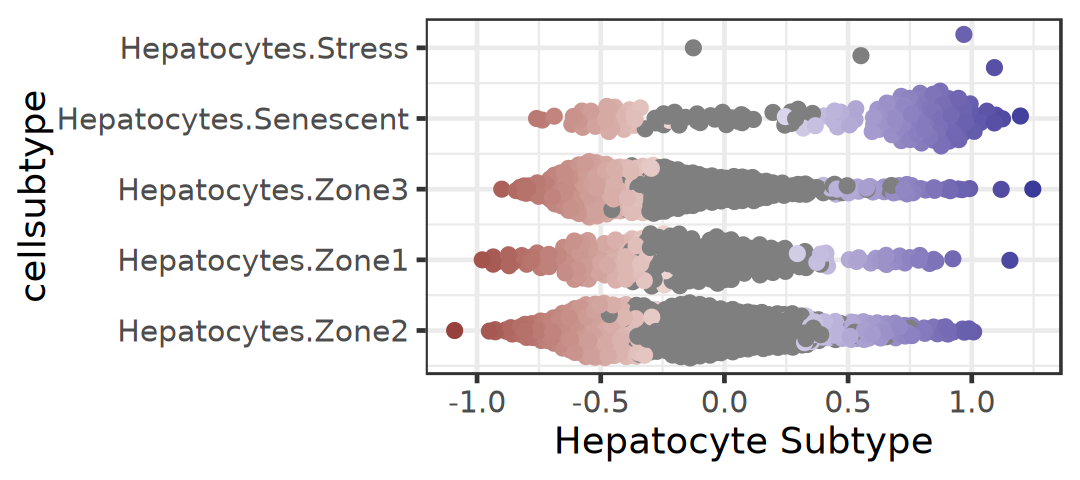

In [10]:
options(repr.plot.width=9, repr.plot.height=4)
p1 <- plotDAbeeswarm(fib_results, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL) +
    labs(y='Hepatocyte Subtype')
p1
options(repr.plot.width=8)

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260528_Fibrosis_Beeswarm.pdf', width=9, height =4)

Converting group_by to factor...



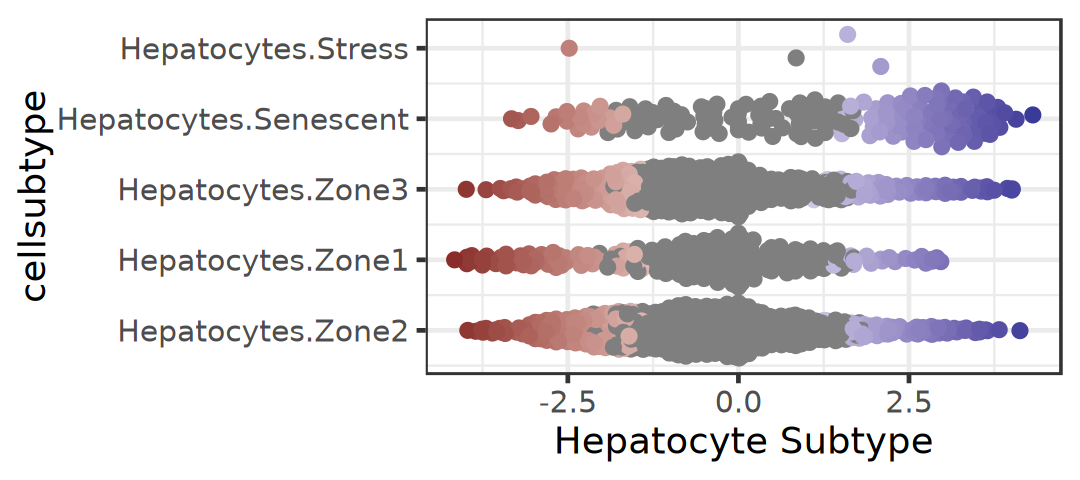

In [12]:
options(repr.plot.width=9, repr.plot.height=4)
p1 <- plotDAbeeswarm(cond_results, group.by = 'cellsubtype', alpha = 0.1, subset.nhoods = NULL) +
    labs(y='Hepatocyte Subtype')
p1
options(repr.plot.width=8)

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260528_Condition_Beeswarm.pdf', width=9, height =4)

In [44]:
list.files('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/', pattern='tsv')

[1] "260511_WE_miloR_Hep_Subtypes_results_condition.tsv"          
[2] "260511_WE_miloR_Hep_Subtypes_results_Fib-MASH_vs_Control.tsv"
[3] "260511_WE_miloR_Hep_Subtypes_results_Fib+MASH_vs_Control.tsv"
[4] "260511_WE_miloR_Hep_Subtypes_results_fibrosis.tsv"           
[5] "260511_WE_miloR_Hep_Subtypes_results_MASH_vs_Control.tsv"    
[6] "260511_WE_miloR_Hep_Subtypes_results_MASL_vs_Control.tsv"    
[7] "260511_WE_miloR_Hep_Subtypes_results_MetALD_vs_Control.tsv"  
[8] "260511_WE_miloR_Hep_Subtypes_results.tsv"

In [49]:
library(stringr)
res.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/'
all.res <- data.frame() 

for (file in list.files(res.dir, pattern='tsv')) {
    if (file %in% c('260511_WE_miloR_Hep_Subtypes_results_condition.tsv','260511_WE_miloR_Hep_Subtypes_results.tsv')) {
        next
    }
    all.res <- read.table(paste0(res.dir, file), header=T) %>%
        mutate(Contrast=str_remove(str_remove(file, '260511_WE_miloR_Hep_Subtypes_results_'), '.tsv')) %>%
        bind_rows(all.res)
}

all.res <- mutate(all.res, Contrast=ifelse(Contrast=='fibrosis', 'Fibrosis.stage', Contrast))

all.res

logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,cellsubtype,cellsubtype_fraction,Contrast
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<chr>
1.10165214,12.18821,3.43430616,0.1496863314,0.271111839,1,0.262830813,Hepatocytes.Zone2,0.6250000,MetALD_vs_Control
-3.90671641,12.37818,14.76399801,0.0001218877,0.001576577,2,0.001489296,Hepatocytes.Zone1,0.9600000,MetALD_vs_Control
-3.25000493,12.26194,14.68443342,0.0001271413,0.001576577,3,0.001489296,Hepatocytes.Zone2,0.5384615,MetALD_vs_Control
0.33221941,12.31653,0.15752676,0.8579498771,0.973806308,4,0.982542483,Hepatocytes.Zone2,0.9375000,MetALD_vs_Control
-0.51318312,12.30080,0.33632350,0.5619599270,0.717683762,5,0.714097040,Hepatocytes.Zone2,0.9285714,MetALD_vs_Control
-2.67109026,12.23447,13.23850759,0.0002743443,0.002119227,6,0.002082629,Hepatocytes.Zone2,0.9090909,MetALD_vs_Control
-0.64194004,12.24399,0.80004517,0.3710812422,0.503257669,7,0.498440237,Hepatocytes.Zone1,0.6363636,MetALD_vs_Control
1.91982862,12.25112,7.40738713,0.0271800710,0.076829001,8,0.075453316,Hepatocytes.Zone2,0.7916667,MetALD_vs_Control
1.26832960,12.17042,4.92285693,0.0641744930,0.149871412,9,0.142422275,Hepatocytes.Zone2,0.6470588,MetALD_vs_Control


In [50]:
write.table(all.res, paste0(res.dir, '260511_WE_miloR_Hep_Subtypes_results_combined.tsv'), sep='\t', col.names=T, row.names=F, quote=F)

In [51]:
paste0(res.dir, '260511_WE_miloR_Hep_Subtypes_results_combined.tsv')

[1] "/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/14_Trajectory/miloR/260511_WE_miloR_Hep_Subtypes_results_combined.tsv"